# FakeReasoning — architecture and single-GPU LoRA fine-tuning

Runs the official **FakeReasoning** checkpoint — dual CLIP + DINOv2 vision towers, a
cross-attention fusion module, and a LLaVA/Vicuna language decoder — and adds a
single-GPU LoRA/QLoRA fine-tuning workflow on top of it.

**Three places you edit:** `LOAD_4BIT` in §3, `FinetuneConfig` in §6, `MMFR_WEIGHT` in §7f.

Fine-tuning an already-specialised checkpoint is a *preservation* problem, not a fitting
problem. The base model already detects forgeries and explains them; the job is to add
coverage without spending what is already there. Concretely:

1. **Touch as little as possible** — LoRA on the language decoder only. Both vision
   towers and the released fusion module stay exactly as published, and §8 asserts it.
2. **Rehearse the old distribution while learning the new one** — MMFR (the
   checkpoint's own training data) mixed with a deduplicated slice of FakeClue.
3. **Measure where the damage would show** — in-distribution accuracy can rise while the
   model gets worse. §14 scores generators the training data never contained.

This is not a replacement for the authors' multi-GPU DeepSpeed script
(`LLaVA/finetune_task_lora.sh`); it is a lighter path for iterating on one GPU.

A full walkthrough of the architecture and of every fine-tuning decision is in the
companion document `fakereasoning_explained.md`.

## 1. Environment

FakeReasoning ships its own fork of LLaVA. The fork calls `transformers` internals that
moved after 4.37, so the four pinned versions below are load-bearing — a newer
`transformers` imports fine and then fails at `generate()` or at `Trainer` setup.

This cell restarts nothing on its own: run it, restart the kernel, then continue.

In [1]:
import os
import subprocess
import sys
from pathlib import Path

os.environ["USE_TF"] = "0"
os.environ["USE_FLAX"] = "0"
os.environ["TRANSFORMERS_NO_TF"] = "1"

# Two roots, split by what it costs to lose them. PROJECT_ROOT holds the dataset
# subsets §7 builds and your checkpoints — slow to rebuild, worth keeping. SCRATCH
# holds the model weights, the cloned repo and the Hub cache — one command re-fetches
# any of it. Together they need ~25 GB.
#
#   workstation   PROJECT_ROOT = Path.home() / "fakereasoning"   (one disk is fine)
#   HPC / SLURM   PROJECT_ROOT = Path("/scratch/$USER/fakereasoning")
#                 NOT your home directory — cluster homes are small-quota and slow.
#   Kaggle        PROJECT_ROOT = Path("/kaggle/working")   hard 20 GB, kept by Save Version
#                 SCRATCH      = Path("/kaggle/temp")      ~60 GB, wiped at session end
PROJECT_ROOT = Path.home() / "fakereasoning"
SCRATCH = PROJECT_ROOT / "scratch"

SCRATCH.mkdir(parents=True, exist_ok=True)
os.environ["HF_HOME"] = str(SCRATCH / "huggingface")

REPO_DIR = SCRATCH / "FakeReasoning"
LLAVA_DIR = REPO_DIR / "LLaVA"

# False if you installed the stack yourself (conda/venv). True on a hosted runtime
# where the environment resets — then restart the kernel once when it finishes.
INSTALL = False

if not LLAVA_DIR.is_dir():
    subprocess.check_call(
        ["git", "clone", "https://github.com/PRIS-CV/FakeReasoning.git", str(REPO_DIR)]
    )

if INSTALL:
    pip = [sys.executable, "-m", "pip", "install", "-q"]

    subprocess.check_call(pip + [
        "bitsandbytes", "peft==0.7.1", "einops-exts==0.0.4", "nltk", "rouge-score",
        "markdown2", "pillow", "shortuuid", "sentencepiece", "protobuf", "seaborn",
        "scikit-learn",
    ])

    # --no-deps so pip cannot resolve these back up to a newer transformers.
    subprocess.check_call(pip + [
        "--force-reinstall", "--no-deps",
        "transformers==4.37.2", "tokenizers==0.15.2",
        "huggingface-hub==0.36.0", "accelerate==0.21.0",
    ])

    # The LLaVA fork, installed editable from the cloned repo.
    subprocess.check_call(pip + ["--no-deps", "--no-build-isolation", "-e", str(LLAVA_DIR)])

    print("Installed — RESTART THE KERNEL now, then run the next cell.")
else:
    # The path below is the one that matters: it must be your environment's python,
    # not a system one. If it is wrong, Jupyter picked the wrong kernel and nothing
    # you installed is visible to this notebook.
    print("INSTALL is False — using the environment as it is, no restart needed.")
    print(" ", sys.executable)

INSTALL is False — using the environment as it is, no restart needed.
  /home/alfawzai/miniconda3/envs/fakereasoning/bin/python


In [2]:
import os

os.environ["USE_TF"] = "0"
os.environ["USE_FLAX"] = "0"
os.environ["TRANSFORMERS_NO_TF"] = "1"
# The Hub cache stages every download here before it lands, including MMFR's 500 MB
# parts. It must be on the scratch volume, not on /kaggle/working's 20 GB quota and
# not on a small /tmp.
from pathlib import Path
os.environ["HF_HOME"] = str(Path.home() / "fakereasoning" / "scratch" / "huggingface")

import accelerate
import bitsandbytes
import huggingface_hub
import tokenizers
import torch
import transformers

# These four must read exactly 4.37.2 / 0.15.2 / 0.36.0 / 0.21.0.
print("transformers     :", transformers.__version__)
print("tokenizers       :", tokenizers.__version__)
print("huggingface-hub  :", huggingface_hub.__version__)
print("accelerate       :", accelerate.__version__)
print("bitsandbytes     :", bitsandbytes.__version__)
print("torch            :", torch.__version__)

assert torch.cuda.is_available(), "Enable a GPU."
print(f"\nGPU: {torch.cuda.get_device_name(0)}  "
      f"({torch.cuda.get_device_properties(0).total_memory / 1024 ** 3:.0f} GB)")

transformers     : 4.37.2
tokenizers       : 0.15.2
huggingface-hub  : 0.36.0
accelerate       : 0.21.0
bitsandbytes     : 0.50.0
torch            : 2.7.1+cu126

GPU: NVIDIA A100-SXM4-80GB  (79 GB)


## 2. Weights

Three separate downloads, because the released checkpoint is not self-contained:

| what | where from | what it is |
|---|---|---|
| `AnnaGao/FakeReasoning` | HF | the fine-tuned LLaVA decoder + both projectors + the cross-attention fusion module |
| `openai/clip-vit-large-patch14-336` | HF | the CLIP vision tower — **weights are not in the checkpoint**, only a path to them |
| `dinov2_vitl14_pretrain.pth` | Meta | the DINOv2 vision tower, loaded from disk by path, not from HF |

The DINO tower reads `DINO_PATH` and `DINO_WEIGHT` out of the environment when it is
constructed, so both have to be set before the model loads in §3. The released
`config.json` points `mm_vision_tower` at the authors' own filesystem, so it gets
repointed at the local CLIP copy here.

**Two roots, and `HF_HOME`.** `PROJECT_ROOT` keeps what is slow to rebuild — the §7
dataset subsets (~8 GB) and your checkpoints. `SCRATCH` holds the ~17 GB of model
weights, the cloned repo, and the Hub cache, all of which one command re-fetches.
Locally they can share a disk.

On Kaggle they must not: `/kaggle/working` is a hard 20 GB and is the only thing "Save
Version" keeps, while everything else is ~60 GB of scratch that disappears at session
end. Set `PROJECT_ROOT = Path("/kaggle/working")` and `SCRATCH = Path("/kaggle/temp")`
there, in **both** §1 and §2 — §1 runs before the kernel restart, §2 after, and if they
disagree the Hub cache lands somewhere you did not intend.

In [3]:
import json
import os
import sys
from pathlib import Path

import torch
from huggingface_hub import snapshot_download

PROJECT_ROOT = Path.home() / "fakereasoning"   # same two values as §1
SCRATCH = PROJECT_ROOT / "scratch"
DATA_ROOT = PROJECT_ROOT / "data"              # the dataset subsets built in §7

SCRATCH.mkdir(parents=True, exist_ok=True)
# Set before anything touches the Hub. Every download stages here first, including
# MMFR's 500 MB parts, so it belongs on the volume with room rather than in ~/.cache.
os.environ["HF_HOME"] = str(SCRATCH / "huggingface")

REPO_DIR = SCRATCH / "FakeReasoning"
LLAVA_DIR = REPO_DIR / "LLaVA"
DINO_DIR = REPO_DIR / "dinov2-main"

WEIGHTS_ROOT = SCRATCH / "weights"         # ~17 GB, re-downloadable, so not persisted
MODEL_DIR = WEIGHTS_ROOT / "FakeReasoning"
CLIP_DIR = WEIGHTS_ROOT / "clip-vit-large-patch14-336"
DINO_WEIGHT = WEIGHTS_ROOT / "dinov2_vitl14_pretrain.pth"

WEIGHTS_ROOT.mkdir(parents=True, exist_ok=True)

# Read by DINOVisionTower at construction time -- must be set before §3 loads.
os.environ["DINO_PATH"] = str(DINO_DIR)
os.environ["DINO_WEIGHT"] = str(DINO_WEIGHT)
sys.path.insert(0, str(LLAVA_DIR))

snapshot_download(repo_id="AnnaGao/FakeReasoning", local_dir=str(MODEL_DIR))

snapshot_download(
    repo_id="openai/clip-vit-large-patch14-336",
    local_dir=str(CLIP_DIR),
    allow_patterns=["config.json", "preprocessor_config.json", "pytorch_model.bin"],
)

if not DINO_WEIGHT.is_file():
    torch.hub.download_url_to_file(
        "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitl14/dinov2_vitl14_pretrain.pth",
        str(DINO_WEIGHT),
    )

config_path = MODEL_DIR / "config.json"
model_config = json.loads(config_path.read_text(encoding="utf-8"))
model_config["mm_vision_tower"] = str(CLIP_DIR)
config_path.write_text(json.dumps(model_config, indent=2), encoding="utf-8")

print("checkpoint :", MODEL_DIR)
print("clip       :", CLIP_DIR)
print("dino       :", DINO_WEIGHT)
print("dino repo  :", DINO_DIR)

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

config.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

checkpoint : /home/alfawzai/fakereasoning/scratch/weights/FakeReasoning
clip       : /home/alfawzai/fakereasoning/scratch/weights/clip-vit-large-patch14-336
dino       : /home/alfawzai/fakereasoning/scratch/weights/dinov2_vitl14_pretrain.pth
dino repo  : /home/alfawzai/fakereasoning/scratch/FakeReasoning/dinov2-main


## 3. Load the model — EDIT `LOAD_4BIT`

`load_pretrained_model()` builds the whole stack: CLIP tower, DINOv2 tower, the two
projectors that map each tower's patch features into the decoder's embedding space, the
cross-attention module that fuses them, and the Vicuna decoder.

4-bit quantisation (bitsandbytes NF4) applies to the decoder's linear layers only. The
vision towers, the projectors and the fusion module stay in fp16 either way — they are
the part that has to keep its precision, and they are small next to the 7B decoder.

In [4]:
import torch

from llava.mm_utils import get_model_name_from_path
from llava.model.builder import load_pretrained_model

LOAD_4BIT = True   # change this to False if you have a good gpu

# LLaVA's builder loads fp16, and the 4-bit path pins its compute dtype to fp16, so
# training stays fp16 -- FinetuneConfig.precision in §6 must say "fp16" to match.
# To train bf16 on an A100: set LOAD_4BIT = False, pass torch_dtype=torch.bfloat16
# below, and set precision = "bf16" in §6. All three change together or not at all.
tokenizer, model, image_processor, context_len = load_pretrained_model(
    model_path=str(MODEL_DIR),
    model_base=None,
    model_name=get_model_name_from_path(str(MODEL_DIR)),
    load_8bit=False,
    load_4bit=LOAD_4BIT,
    device_map="auto",
    device="cuda",
)
model.eval()

# Training and inference must agree on the image-token format. §9's conversation builder
# always emits the bare <image> token, so this flag has to be False on the checkpoint.
assert not model.config.mm_use_im_start_end

base = model.get_model()
print("\ncomponent parameter counts")
for label, module in (
    ("CLIP ViT-L/14-336 tower", model.get_vision_tower()),
    ("DINOv2 ViT-L/14 tower", model.get_dino_vision_tower()),
    ("mm_projector (CLIP -> decoder)", base.mm_projector),
    ("dino_mm_projector (DINO -> decoder)", base.dino_mm_projector),
    ("crossattention (CLIP x DINO fusion)", base.crossattention),
):
    print(f"  {label:<38}{sum(p.numel() for p in module.parameters()) / 1e6:>8.1f}M")

print(f"\ncontext length: {context_len}")
print(f"allocated: {torch.cuda.memory_allocated() / 1024 ** 3:.2f} GB")


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

/home/alfawzai/fakereasoning/scratch/FakeReasoning/dinov2-main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/alfawzai/fakereasoning/scratch/FakeReasoning/dinov2-main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/alfawzai/fakereasoning/scratch/FakeReasoning/dinov2-main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


loading: dual-branch visual encoder

component parameter counts
  CLIP ViT-L/14-336 tower                  303.5M
  DINOv2 ViT-L/14 tower                    607.9M
  mm_projector (CLIP -> decoder)            15.7M
  dino_mm_projector (DINO -> decoder)       15.7M
  crossattention (CLIP x DINO fusion)      157.4M

context length: 2048
allocated: 8.70 GB


## 4. Inference

The official prompt and preprocessing, wrapped so every later section can reuse them.

The checkpoint answers in a four-block schema — `<SUMMARY>`, `<CAPTION>`, `<REASONING>`,
`<CONCLUSION>`. `<CAPTION>` is where it grounds the answer in *this* image, so any
training target that drops those blocks trains the model to stop producing them; §7b
rebuilds the schema for that reason.

`repetition_penalty` and `no_repeat_ngram_size` are not cosmetic. Plain greedy decoding
falls into "the image is sharp and well-defined, with no visible noise…" loops that eat
the whole token budget before `<CONCLUSION>` is reached, and the answer then scores as
unparseable.

In [5]:
import time
from pathlib import Path

from PIL import Image

from llava.constants import DEFAULT_IMAGE_TOKEN, IMAGE_TOKEN_INDEX
from llava.conversation import conv_templates
from llava.mm_utils import process_images, tokenizer_image_token

CONV_MODE = "llava_v1"   # the template the checkpoint was trained with; §9 reuses it

OFFICIAL_PROMPT = (
    "Is this image real or fake? Please describe the image, "
    "reasoning step-by-step and conclude with 'this image is real' "
    "or 'this image is fake'."
)


def build_input_ids(prompt=OFFICIAL_PROMPT, model=None, tokenizer=None):
    model = model or globals()["model"]
    tokenizer = tokenizer or globals()["tokenizer"]

    conv = conv_templates[CONV_MODE].copy()
    conv.append_message(conv.roles[0], DEFAULT_IMAGE_TOKEN + "\n" + prompt)
    conv.append_message(conv.roles[1], None)

    return tokenizer_image_token(
        conv.get_prompt(), tokenizer, IMAGE_TOKEN_INDEX, return_tensors="pt"
    ).unsqueeze(0).to(model.device)


# The released checkpoint ends on "this image is real"; a model fine-tuned on raw
# FakeClue answers leads with "This is a real image." instead. Both phrasings count,
# and the LAST one in the text wins, so a long answer that restates itself is scored
# on its conclusion.
VERDICT_PHRASES = {
    "real": ("this image is real", "this is a real image"),
    "fake": ("this image is fake", "this is a fake image"),
}


def extract_prediction(output):
    normalized = " ".join(output.lower().split())
    positions = {
        label: max(normalized.rfind(phrase) for phrase in phrases)
        for label, phrases in VERDICT_PHRASES.items()
    }
    if positions["real"] == -1 and positions["fake"] == -1:
        return "unknown"
    return "real" if positions["real"] > positions["fake"] else "fake"


def run_inference(image_path, max_new_tokens=512, model=None, tokenizer=None,
                  image_processor=None):
    model = model or globals()["model"]
    tokenizer = tokenizer or globals()["tokenizer"]
    image_processor = image_processor or globals()["image_processor"]

    image = Image.open(image_path).convert("RGB")
    # The image tensor has to match the vision tower's dtype: fp16 under a 4-bit
    # load, bf16 under an unquantised bf16 load.
    dtype = next(model.get_vision_tower().parameters()).dtype
    image_tensor = process_images([image], image_processor, model.config).to(
        model.device, dtype=dtype
    )

    input_ids = build_input_ids(model=model, tokenizer=tokenizer)
    started = time.perf_counter()

    with torch.inference_mode():
        output_ids = model.generate(
            inputs=input_ids,              # peft's generate() is keyword-only
            images=image_tensor,
            image_sizes=None,
            do_sample=False,
            num_beams=1,
            max_new_tokens=max_new_tokens,
            repetition_penalty=1.1,
            no_repeat_ngram_size=20,
            use_cache=True,
        )

    elapsed = time.perf_counter() - started
    output = tokenizer.batch_decode(output_ids, skip_special_tokens=True)[0].strip()

    return {
        "image_path": str(image_path),
        "predicted_label": extract_prediction(output),
        "inference_seconds": round(elapsed, 2),
        "explanation": output,
        "truncated": "<CONCLUSION>" not in output,
    }


print("Inference ready.")

Inference ready.


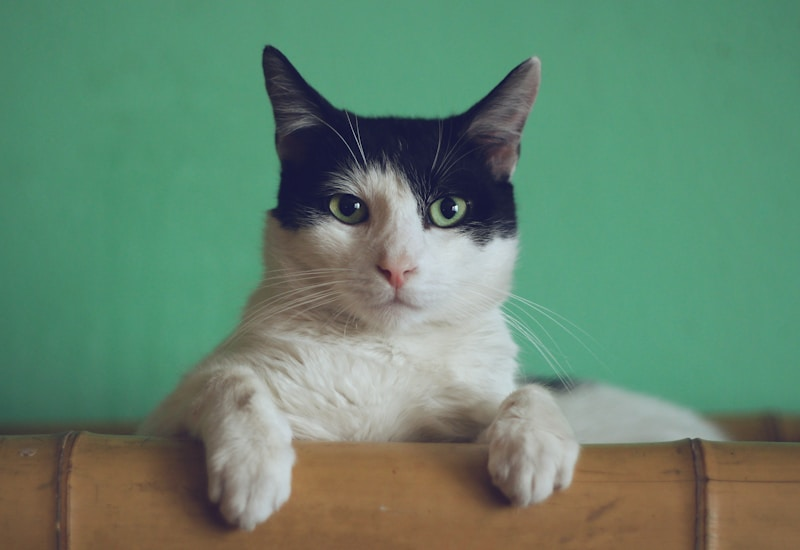

ground truth: real
prediction  : real (18.14s)

<SUMMARY> I will determine if the image is real or fake by analyzing its content and identifying forgery attributes from both low-level and high-level perspectives. I will then conclude by stating either 'this image is real' or 'this image is fake' based on my analysis. </SUMMARY>

<CAPTION> The image shows a black and white cat with striking green eyes, sitting on a wooden surface against a vibrant teal background. The cat appears calm and curious, looking directly at the camera with its paws resting on the edge of the surface. The lighting highlights the cat's fur texture and the warm tones of the wood beneath it. </CAPTION>

<REASONING> From low-level perspective: The textures of the cat's fur and the wooden surface appear natural and consistent throughout the image.The edges around the cat and the wooden surface are smooth and blend naturally into the background.The lighting on the cat and the shadows cast are consistent with a single

In [6]:
# Sanity check on a known real photograph.
import requests
from IPython.display import display

SAMPLE_IMAGE = Path("/tmp/sample_real_cat.jpg")

if not SAMPLE_IMAGE.is_file():
    response = requests.get(
        "https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba?w=800", timeout=120
    )
    response.raise_for_status()
    SAMPLE_IMAGE.write_bytes(response.content)

display(Image.open(SAMPLE_IMAGE).convert("RGB"))

sample_result = run_inference(SAMPLE_IMAGE)
print("ground truth:", "real")
print("prediction  :", sample_result["predicted_label"],
      f"({sample_result['inference_seconds']}s)")
print("\n" + sample_result["explanation"])

In [7]:
from pathlib import Path
root = Path.home() / "fakereasoning" / "data"
img = root / "fakeclue" / "images"

print("fakeclue markers :", [p.name for p in img.glob(".*extracted")] or "none")
print("fakeclue images  :", sum(1 for _ in img.rglob("*.jpg")))
print("mmfr subset      :", (root / "mmfr" / ".subset.json").exists())
print("mmfr images      :", sum(1 for _ in (root / "mmfr").rglob("*.jpg")))

fakeclue markers : ['.train.extracted', '.test.extracted']
fakeclue images  : 37214
mmfr subset      : True
mmfr images      : 60747


---

# Part II — Fine-tuning

## 5. What gets trained, and what does not

| component | params | default | why |
|---|---|---|---|
| Vicuna decoder | ~6.7B | **LoRA, r=16** | the only thing that needs to move |
| CLIP ViT-L/14-336 tower | 303M | **frozen** | semantic features; the generalisation budget |
| DINOv2 ViT-L/14 tower | 304M | **frozen** | texture/artifact features; ditto |
| `crossattention` fusion | ~315M | **frozen** | released, task-specific, trained on 100K images |
| `mm_projector` + `dino_mm_projector` | ~63M | **frozen** | released; retraining them moves the whole feature interface |

LoRA on the decoder alone is ~40M trainable parameters — about 0.5% of the stack.
Everything else in this notebook exists to keep it that way and to prove that it stayed
that way:

* `modules_to_save` is **empty**. Anything listed there is *fully* fine-tuned — peft
  opts out of LoRA for it and keeps a frozen fp32 copy besides.
* Both towers are **`"frozen"`**, which leaves the released `@torch.no_grad()` forward
  in place rather than replacing it.
* §8 builds an **anchored regex** for peft's `target_modules` instead of bare leaf
  names. peft suffix-matches a bare name like `q_proj` against *every* module in the
  model, and CLIP's attention blocks have `q_proj` too — so bare names inject LoRA into
  the vision towers and `"frozen"` silently means nothing. The regex, plus
  `assert_no_lora_outside_llm()`, makes the freeze a verified post-condition.

## 6. Configuration — EDIT HERE

One dataclass drives everything below it. The defaults are a preservation profile.

### Smoke-testing first

The full data build is ~45 minutes of FakeClue extraction plus 40–90 minutes of MMFR
streaming, and it is a miserable way to discover that a dtype is wrong in §10. To prove
the whole pipeline runs end to end in about five minutes, set three things:

```python
USE_MMFR = False                                 # §7d — skips the 42 GB stream entirely
FAKECLUE_EVAL_MAX_PER_CLASS = 10                 # §7b — 20 held-out images
max_train_examples = 40                          # here — 40 training images
eval_steps = save_steps = 1                      # here — or neither ever fires
```

That fetches ~60 images, trains for a couple of optimizer steps, saves an adapter and
reloads it. Everything is exercised except the numbers meaning anything.

`eval_steps` matters more than it looks. The effective batch is 16, so 40 examples is
two steps — leave `eval_steps` at 50 and validation never runs, `save_steps` never
fires, and you have not actually tested the two things most likely to break on a long
run. Set them back afterwards; §7 caches its subsets, so restoring the real values only
fetches what the small run did not already pull.

In [8]:
from dataclasses import dataclass, field
from typing import List, Optional


@dataclass
class FinetuneConfig:
    # --- what to fine-tune ---------------------------------------------------
    base_model_path: str = str(MODEL_DIR)     # any dual CLIP+DINO LLaVA checkpoint
    output_dir: str = str(PROJECT_ROOT / "checkpoints" / "fakereasoning-finetuned")

    # alpha == r gives an adapter scaling of 1.0, which is what you want when adapting
    # an already-specialised checkpoint. r=32 / alpha=64 (scaling 2.0) is
    # LoRA-from-a-base-model territory and will overwrite behaviour worth keeping.
    llm_lora_r: int = 32
    llm_lora_alpha: int = 64
    llm_lora_dropout: float = 0.05
    llm_lora_target_modules: Optional[str] = None   # None -> the anchored regex from §8

    # Anything named here is FULLY fine-tuned, not adapted. The three candidates are
    # "mm_projector", "dino_mm_projector", "crossattention" -- 377M released params.
    # Leave this empty unless §14 proves that training them helps.
    modules_to_save: List[str] = field(default_factory=list)

    # "frozen" | "lora" | "full". Frozen is correct: CLIP and DINOv2 features carry the
    # generalisation to images outside the training set. Unfreeze one tower at a time,
    # and only if §14 says the freeze is what's holding you back.
    dino_finetune_mode: str = "frozen"
    dino_lora_r: int = 8
    dino_lora_alpha: int = 8
    dino_lora_dropout: float = 0.05

    clip_finetune_mode: str = "frozen"
    clip_lora_r: int = 8
    clip_lora_alpha: int = 8
    clip_lora_dropout: float = 0.05

    # --- optimisation (each group gets its own LR, see MultiLRTrainer in §9) ---
    llm_learning_rate: float = 1e-5           # 2e-4 is for LoRA from a base model
    projector_learning_rate: float = 1e-5    # only used if modules_to_save is non-empty
    vision_learning_rate: float = 5e-6       # only used if a tower is unfrozen
    num_train_epochs: float = 1
    per_device_train_batch_size: int = 4
    gradient_accumulation_steps: int = 4     # effective batch 16
    warmup_ratio: float = 0.03
    max_grad_norm: float = 0.3               # QLoRA's value; keeps single steps small
    model_max_length: int = 2048
    image_aspect_ratio: str = "pad"          # must match the official preprocessing

    # --- dataset shaping (see §7b and §7c) -----------------------------------
    # A quality control, not a resource cap: it drops answers that already appeared
    # three times, so the model cannot learn "recognise the category, recite its
    # paragraph". On FakeClue's train split ~89% of answers are already unique, so
    # this removes roughly 10% and is not what limits your dataset size.
    max_duplicate_answers: int = 3

    # Total training records, split between MMFR and FakeClue by mmfr_weight below.
    # At effective batch 16 this is examples/16 optimizer steps -- 60k is ~3,750 steps,
    # a few hours on an A100. FakeClue alone can supply ~66k balanced records and MMFR
    # ~100k, so this is the number that decides run length, not availability.
    max_train_examples: int = 20_000

    # Share of the mixture drawn from MMFR; FakeClue supplies the rest. It lives here
    # rather than in §7f because §7b needs it too — it plans FakeClue at exactly its
    # share so it does not spend thousands of downloads on images the mixture will
    # discard. Change it here, then re-run §7b.
    mmfr_weight: float = 0.75

    # Categories to drop before anything else. FakeClue's satellite and document images
    # are a different problem from natural-image forgery detection, so excluding them
    # concentrates the budget on the domains you care about. Empty set keeps all seven.
    exclude_categories: frozenset = frozenset({"satellite", "doc"})

    # --- validation / checkpointing ------------------------------------------
    eval_examples: int = 200      # held-out slice scored for validation loss
    eval_steps: int = 50
    save_steps: int = 50
    save_total_limit: int = 4

    # --- precision / memory ---------------------------------------------------
    precision: str = "fp16"            # must match the load dtype chosen in §3
    keep_frozen_vision_fp16: bool = True   # see §8: undoes prepare_model_for_kbit's upcast
    use_8bit_optimizer: bool = True


FINETUNE_CONFIG = FinetuneConfig()

for key, value in FINETUNE_CONFIG.__dict__.items():
    print(f"  {key}: {value}")

  base_model_path: /home/alfawzai/fakereasoning/scratch/weights/FakeReasoning
  output_dir: /home/alfawzai/fakereasoning/checkpoints/fakereasoning-finetuned
  llm_lora_r: 32
  llm_lora_alpha: 64
  llm_lora_dropout: 0.05
  llm_lora_target_modules: None
  modules_to_save: []
  dino_finetune_mode: frozen
  dino_lora_r: 8
  dino_lora_alpha: 8
  dino_lora_dropout: 0.05
  clip_finetune_mode: frozen
  clip_lora_r: 8
  clip_lora_alpha: 8
  clip_lora_dropout: 0.05
  llm_learning_rate: 1e-05
  projector_learning_rate: 1e-05
  vision_learning_rate: 5e-06
  num_train_epochs: 1
  per_device_train_batch_size: 4
  gradient_accumulation_steps: 4
  warmup_ratio: 0.03
  max_grad_norm: 0.3
  model_max_length: 2048
  image_aspect_ratio: pad
  max_duplicate_answers: 3
  max_train_examples: 20000
  mmfr_weight: 0.75
  exclude_categories: frozenset({'doc', 'satellite'})
  eval_examples: 200
  eval_steps: 50
  save_steps: 50
  save_total_limit: 4
  precision: fp16
  keep_frozen_vision_fp16: True
  use_8bit_op

## 7. Data

Two sources, deliberately.

**MMFR-Dataset** ([AnnaGao/MMFR-Dataset](https://huggingface.co/datasets/AnnaGao/MMFR-Dataset))
is FakeReasoning's *own* training set: 50K fake (DiffusionDB) + 50K real
(LAION-Aesthetics) with 378K GPT-4o reasoning annotations written **one image at a
time**, plus evaluation sets across ten generators. It is the rehearsal half — mixing
the original distribution back in is the standard remedy for catastrophic forgetting,
and its per-image targets are what teach image-conditional reasoning.

**FakeClue** ([lingcco/FakeClue](https://huggingface.co/datasets/lingcco/FakeClue))
covers domains MMFR does not: satellite imagery, documents, face manipulation. Its
answers are formulaic per (category, label), so it is the half that must be
deduplicated before it can be trusted.

Four things about FakeClue have to be handled, and §7b handles all four:

1. its numeric label field is inverted (`0 = fake`, `1 = real`), so labels come from the
   image path instead;
2. its answers carry no `<CONCLUSION>` tag and state the verdict in the first sentence;
3. it uses a two-block schema, so training on it raw teaches the model to stop emitting
   `<SUMMARY>` and `<CAPTION>`;
4. its answers repeat across hundreds of images.

**Licences:** FakeClue is Apache-2.0, MMFR is CC BY-NC-SA 4.0 (non-commercial,
share-alike). A model fine-tuned on the mixture inherits the more restrictive of the two.

### Storage — why neither dataset is downloaded whole

Between them these two archives are ~70 GB compressed and need well over 100 GB to
extract. Kaggle has 20 GB persistent plus ~60 GB of scratch, so the naive path does not
fit and never will. But the training config only asks for **6,000 FakeClue-plus-MMFR
examples and 200 evaluation images** — roughly 3% of what is in those archives. The two
cells below fetch that 3% and nothing else, using the fact that the two formats fail
differently:

* **ZIP is random-access.** It has a central directory at the end, so a single member
  can be read with an HTTP range request. §7b plans the selection from the annotation
  JSON first, then pulls exactly those images out of the remote `train.zip` — a few
  thousand small range reads instead of a 28 GB download.
* **TAR is sequential.** No index, no seeking, and MMFR's is split across 86 parts. So
  §7d streams it: fetch a part, read it through a `tarfile` in stream mode, extract what
  passes the quota, delete the part, fetch the next. All 42 GB crosses the network, but
  peak disk is one 500 MB part plus what you keep.

Expect **~5 GB on disk** and **40–90 minutes** for the MMFR stream. Both cells are
resumable: they record what they built and skip the work on a re-run.

**Do this once.** The subsets land in `/kaggle/working/data` (~5 GB, well under the
20 GB cap), so after the first run hit *Save Version*, then attach this notebook's
output as a dataset in your next session and skip §7 entirely.

### 7a. FakeClue — annotations only

In [9]:
import json
import random
import shutil
import struct
import threading
import time
import zipfile
import zlib
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

from huggingface_hub import HfFileSystem, hf_hub_download

# Range requests are latency-bound, not bandwidth-bound: each one is a round trip for
# a few hundred KB. Serially, 48k members is hours of waiting on the network with the
# link idle. Concurrency is the entire win here. Raise it if the Hub keeps up; drop it
# if you start seeing 429s.
FETCH_WORKERS = 16

FAKECLUE_REPO = "lingcco/FakeClue"
FAKECLUE_ROOT = DATA_ROOT / "fakeclue"
FAKECLUE_IMAGES = FAKECLUE_ROOT / "images"
FAKECLUE_IMAGES.mkdir(parents=True, exist_ok=True)

FAKECLUE_TRAIN_SPLIT = "train"
FAKECLUE_EVAL_SPLIT = "test"

# How the images arrive. The annotation JSON is a few MB and comes down either way.
#
#   True   Download <split>.zip whole and extract it: ~27 GB transferred, ~55 GB peak
#          disk (cached archive plus extracted tree), settling at ~28 GB. One
#          sequential transfer at full bandwidth, and afterwards every change to
#          max_train_examples, exclude_categories or mmfr_weight is free — the images
#          are already local.
#   False  Pull only the planned members by HTTP range request: ~2 GB on disk, but one
#          round trip per image, and changing the plan means going back to the Hub.
#          This is the mode for a machine with no room, e.g. Kaggle's 20 GB.
#
# The crossover is roughly "am I keeping more than a fifth of the archive": above that,
# the whole-file download wins on wall clock even though it moves more bytes.
FAKECLUE_FULL_DOWNLOAD = True


def load_annotations(split):
    return json.loads(Path(hf_hub_download(
        repo_id=FAKECLUE_REPO, repo_type="dataset",
        filename=f"data_json/{split}.json")).read_text())


def extract_from_remote_zip(split, wanted, dest, workers=FETCH_WORKERS):
    """Pull `wanted` (paths exactly as the annotation JSON writes them) out of
    <split>.zip on the Hub, without downloading the archive.

    Each member is fetched with ONE range request covering exactly its own bytes, and
    that detail is the whole point of this cell. fsspec's default read-ahead cache
    fetches a full block per read, so a 4 MB block turns every 300 KB image into a 4 MB
    transfer: pulling 6000 members out of FakeClue's 28 GB train.zip moves ~26 GB, and
    you may as well have downloaded the archive. Exact ranges move ~1.8 GB."""
    dest = Path(dest)
    fs = HfFileSystem()
    remote = f"datasets/{FAKECLUE_REPO}/{split}.zip"
    print(f"[{split}] {fs.info(remote)['size'] / 1024 ** 3:.1f} GB archive, "
          f"{len(wanted)} members wanted")

    # The central directory is one contiguous region at the end of the file, read with
    # many small seeks, so buffering pays off here and only here.
    with fs.open(remote, "rb", block_size=8 * 1024 * 1024) as handle:
        # Member names may carry a leading directory that the JSON's paths do not,
        # so index both forms rather than guessing which layout this zip uses.
        index = {}
        for info in zipfile.ZipFile(handle).infolist():
            index.setdefault(info.filename, info)
            _, _, tail = info.filename.partition("/")
            if tail:
                index.setdefault(tail, info)
    print(f"[{split}] central directory: {len(index)} names")

    missing = [rel for rel in wanted if rel not in index]
    # Ascending offset turns thousands of random seeks into a forward scan.
    todo = sorted(((rel, index[rel]) for rel in wanted if rel in index),
                  key=lambda pair: pair[1].header_offset)

    # One handle per worker thread, reused for every member that thread fetches.
    # fs.open() resolves the repo revision over the API, which costs far more than the
    # range read itself, so opening one per file would undo the point of threading.
    thread_state = threading.local()
    handles, handle_lock = [], threading.Lock()

    def reader():
        handle = getattr(thread_state, "handle", None)
        if handle is None:
            handle = thread_state.handle = fs.open(remote, "rb", cache_type="none")
            with handle_lock:
                handles.append(handle)
        return handle

    def fetch(item):
        rel, info = item
        out = dest / rel
        if out.is_file():
            return False

        # Local header is 30 bytes + filename + extra, and only the header itself says
        # how long the extra field is. Read it together with the data and slice, rather
        # than paying a second round trip per member for 30 bytes.
        raw = reader()
        raw.seek(info.header_offset)
        buf = raw.read(30 + len(info.filename.encode()) + 256 + info.compress_size)
        name_len, extra_len = struct.unpack("<HH", buf[26:30])
        start = 30 + name_len + extra_len
        assert start + info.compress_size <= len(buf), \
            f"{rel}: local header longer than the 256 bytes of slack allowed"
        blob = buf[start:start + info.compress_size]

        assert info.compress_type in (zipfile.ZIP_STORED, zipfile.ZIP_DEFLATED), \
            f"{rel}: unsupported zip compression {info.compress_type}"
        if info.compress_type == zipfile.ZIP_DEFLATED:
            blob = zlib.decompress(blob, -15)          # raw deflate, no zlib wrapper

        out.parent.mkdir(parents=True, exist_ok=True)
        out.write_bytes(blob)
        return True

    written = reused = 0
    started = time.perf_counter()
    with ThreadPoolExecutor(max_workers=workers) as pool:
        for i, did_fetch in enumerate(pool.map(fetch, todo), 1):
            written += did_fetch
            reused += not did_fetch
            if i % 2000 == 0:
                rate = i / (time.perf_counter() - started)
                print(f"  {i}/{len(todo)}   {rate:.0f}/s   "
                      f"eta {(len(todo) - i) / max(rate, 1e-9) / 60:.0f} min", flush=True)

    for handle in handles:
        handle.close()
    print(f"[{split}] {written} fetched, {reused} already on disk, "
          f"{len(missing)} not found in the zip")


def download_and_extract(split, dest):
    """Download <split>.zip whole and unpack it under `dest`."""
    marker = Path(dest) / f".{split}.extracted"
    if marker.exists():
        print(f"[{split}] already extracted under {dest}")
        return

    print(f"[{split}] downloading {split}.zip ...", flush=True)
    archive = hf_hub_download(repo_id=FAKECLUE_REPO, repo_type="dataset",
                              filename=f"{split}.zip")

    with zipfile.ZipFile(archive) as zf:
        members = [i for i in zf.infolist() if not i.is_dir()]
        # The archive may nest everything under one top-level directory; the annotation
        # JSON's paths never include it. Strip it here rather than leaving the two
        # conventions to disagree about where an image lives.
        heads = {m.filename.split("/", 1)[0] for m in members if "/" in m.filename}
        strip = len(heads) == 1
        print(f"[{split}] extracting {len(members)} members"
              f"{f' (stripping {heads.pop()}/)' if strip else ''} ...", flush=True)

        for n, info in enumerate(members, 1):
            rel = info.filename.split("/", 1)[1] if strip else info.filename
            out = Path(dest) / rel
            out.parent.mkdir(parents=True, exist_ok=True)
            with zf.open(info) as src, open(out, "wb") as dst:
                shutil.copyfileobj(src, dst, length=1024 * 1024)
            if n % 20000 == 0:
                print(f"  {n}/{len(members)}", flush=True)

    Path(archive).unlink(missing_ok=True)     # reclaim the cached archive
    marker.write_text("ok")
    print(f"[{split}] done")


train_records = load_annotations(FAKECLUE_TRAIN_SPLIT)

if FAKECLUE_TRAIN_SPLIT == FAKECLUE_EVAL_SPLIT:
    shuffled = list(train_records)
    random.Random(0).shuffle(shuffled)
    cut = max(1, len(shuffled) // 10)
    eval_records, train_records = shuffled[:cut], shuffled[cut:]
else:
    eval_records = load_annotations(FAKECLUE_EVAL_SPLIT)

print(f"\ntrain {len(train_records)} / eval {len(eval_records)} annotation records")

if FAKECLUE_FULL_DOWNLOAD:
    for split in dict.fromkeys((FAKECLUE_TRAIN_SPLIT, FAKECLUE_EVAL_SPLIT)):
        download_and_extract(split, FAKECLUE_IMAGES)
else:
    print("Selective mode: no images yet, the next cell decides which are needed.")


train 104343 / eval 5000 annotation records
[train] already extracted under /home/alfawzai/fakereasoning/data/fakeclue/images
[test] already extracted under /home/alfawzai/fakereasoning/data/fakeclue/images


### 7b. FakeClue — convert to the training format

Balancing happens **within each category** before the categories are merged, so that
resolution, crop style and source corpus cannot stand in for the label. Then duplicate
answers are capped: this is the step that decides whether the model learns detection or
learns to recognise a category and recite its paragraph.

In [10]:
import re
from collections import Counter

from llava.constants import DEFAULT_IMAGE_TOKEN

FAKECLUE_TRAIN_JSON = FAKECLUE_ROOT / "fakeclue_train.json"
FAKECLUE_EVAL_JSON = FAKECLUE_ROOT / "fakeclue_eval.json"
# Only needs to be >= max(eval_examples, COMPARE_N in §13). The file being large costs
# nothing; what costs time is how many of them §13 actually generates on.
FAKECLUE_EVAL_MAX_PER_CLASS = 500

# The checkpoint's <SUMMARY> block is the same sentence on every image. Keeping it in
# the targets costs ~60 constant tokens and preserves the four-block output schema,
# which is the point.
BASE_SUMMARY = (
    "I will determine if the image is real or fake by analyzing its content and "
    "identifying forgery attributes from both low-level and high-level perspectives. "
    "I will then conclude by stating either 'this image is real' or 'this image is "
    "fake' based on my analysis."
)

VERDICT_PREFIX = re.compile(r"^\s*this is an?\s+(real|fake)\s+image[.,;:]?\s*", re.I)


def fakeclue_label(record):
    """Label comes from the image path. FakeClue's numeric field is inverted
    (0 = fake, 1 = real), so the path is both simpler and safer. Records with
    neither word in the path are dropped rather than guessed at."""
    parts = [p.lower() for p in Path(record["image"]).parts]
    return "fake" if "fake" in parts else ("real" if "real" in parts else None)


def to_base_schema(answer, label):
    """Strip FakeClue's leading verdict, keep the evidence, and rebuild the
    checkpoint's own schema around it: evidence first, verdict last.

    No <CAPTION> block is emitted -- a templated caption would be one more thing to
    memorise, and omitting it is better than faking it."""
    body = VERDICT_PREFIX.sub("", answer.strip()).strip()
    body = body or "The image was examined for the usual signs of synthetic generation."
    body = body.rstrip(".") + "."
    return "\n\n".join([
        f"<SUMMARY> {BASE_SUMMARY} </SUMMARY>",
        f"<REASONING> {body} Therefore, this image is {label}. </REASONING>",
        f"<CONCLUSION> This image is {label}. </CONCLUSION>",
    ])


def normalise_answer(text):
    """Collapse an answer to a comparison key. Two answers differing only in a comma
    are the same training target as far as the model is concerned."""
    return re.sub(r"[^a-z0-9 ]+", "", text.lower()).strip()


def convert_fakeclue(records, image_root, out_path, prompt=OFFICIAL_PROMPT, seed=42,
                     exclude_images=(), max_duplicate_answers=None,
                     max_per_class=None, max_total=None, require_image=True):
    """require_image=False plans the selection from the annotations alone, before any
    image has been fetched. The plan then says exactly which images to pull."""
    image_root = Path(image_root)
    rng = random.Random(seed)
    exclude_images = set(exclude_images)
    by_cate = {}
    skipped = Counter()
    answer_seen = Counter()
    answer_pool = Counter()

    # Shuffle first so the duplicate cap keeps a random subset of each template
    # rather than whichever copies happen to come first in the file.
    shuffled = list(records)
    rng.shuffle(shuffled)

    for record in shuffled:
        cate = record.get("cate", "unknown")
        if cate in FINETUNE_CONFIG.exclude_categories:
            skipped["excluded_category"] += 1
            continue

        label = fakeclue_label(record)
        answer = next(
            (c["value"] for c in record.get("conversations", []) if c["from"] == "gpt"), ""
        ).strip()
        image_path = image_root / record["image"]

        if label is None or not answer:
            skipped["unlabelled"] += 1
            continue
        if record["image"] in exclude_images:
            skipped["held_out"] += 1
            continue
        if require_image and not image_path.is_file():
            skipped["missing_image"] += 1
            continue

        key = normalise_answer(answer)
        answer_pool[key] += 1
        if max_duplicate_answers is not None and answer_seen[key] >= max_duplicate_answers:
            skipped["duplicate_answer"] += 1
            continue
        answer_seen[key] += 1

        by_cate.setdefault(cate, {"real": [], "fake": []})[label].append({
            "image": str(image_path),
            "rel_image": record["image"],
            "cate": cate,
            "label": label,
            "conversations": [
                {"from": "human", "value": DEFAULT_IMAGE_TOKEN + "\n" + prompt},
                {"from": "gpt", "value": to_base_schema(answer, label)},
            ],
        })

    # Balance within each category, then scale every category down proportionally if
    # the total exceeds the budget. Categories holding only one class drop out.
    # caps[c] counts one CLASS: category c contributes caps[c] real plus caps[c] fake,
    # so it writes 2*caps[c] records. max_per_class is already per class; max_total is
    # a record count, so it halves before being compared against them.
    caps = {c: min(len(v["real"]), len(v["fake"])) for c, v in by_cate.items()}
    per_class_budget = min(
        [b for b in (max_per_class, None if max_total is None else max_total // 2)
         if b is not None],
        default=None,
    )
    total = sum(caps.values())
    if per_class_budget is not None and total > per_class_budget:
        caps = {c: max(1, int(n * per_class_budget / total)) if n else 0
                for c, n in caps.items()}

    out_records = []
    print(f"  {'category':<18}{'real':>8}{'fake':>8}{'kept/class':>12}")
    for cate in sorted(by_cate):
        pools = by_cate[cate]
        print(f"  {cate:<18}{len(pools['real']):>8}{len(pools['fake']):>8}{caps[cate]:>12}")
        for label in ("real", "fake"):
            pool = list(pools[label])
            rng.shuffle(pool)
            out_records.extend(pool[:caps[cate]])

    rng.shuffle(out_records)
    Path(out_path).write_text(json.dumps(out_records, indent=2))

    n_real = sum(r["label"] == "real" for r in out_records)
    unique, pool_total = len(answer_pool), sum(answer_pool.values())
    print(f"  skipped: {dict(skipped)}")
    print(f"  source answers: {pool_total} total, {unique} unique "
          f"({unique / max(1, pool_total):.1%}) before the cap")
    print(f"  wrote {len(out_records)} examples ({n_real} real / "
          f"{len(out_records) - n_real} fake) to {out_path}")
    return Path(out_path)


# In full-download mode the images are already on disk, so the selection can insist on
# them -- which also proves the extraction landed where the annotations expect. In
# selective mode nothing has been fetched yet, so the plan is built from annotations
# alone and step 2 pulls exactly what it chose.
NEED_IMAGE = FAKECLUE_FULL_DOWNLOAD

# 1. Plan. The eval set is built first and never capped for duplicates: it has to
#    stay a faithful sample of the distribution, and capping it would flatter the model.
print("--- eval set (held out) ---")
convert_fakeclue(eval_records, FAKECLUE_IMAGES, FAKECLUE_EVAL_JSON, seed=7,
                 require_image=NEED_IMAGE, max_per_class=FAKECLUE_EVAL_MAX_PER_CLASS)

held_out = {r["rel_image"] for r in json.loads(FAKECLUE_EVAL_JSON.read_text())}

# Planned at exactly FakeClue's share of the mixture, not the whole budget. Planning
# the full budget and letting §7f subsample would fetch roughly 1/(1-mmfr_weight) times
# what ends up being used — tens of thousands of needless downloads at this size.
print("\n--- train set ---")
convert_fakeclue(train_records, FAKECLUE_IMAGES, FAKECLUE_TRAIN_JSON, seed=42,
                 require_image=NEED_IMAGE, exclude_images=held_out,
                 max_duplicate_answers=FINETUNE_CONFIG.max_duplicate_answers,
                 max_total=int(FINETUNE_CONFIG.max_train_examples
                               * (1.0 - FINETUNE_CONFIG.mmfr_weight)))

# 2. Fetch exactly the images the plan selected. Only selective mode needs this;
#    full-download mode already has all of them.
if not FAKECLUE_FULL_DOWNLOAD:
    wanted_by_split = {}
    for split, path in ((FAKECLUE_EVAL_SPLIT, FAKECLUE_EVAL_JSON),
                        (FAKECLUE_TRAIN_SPLIT, FAKECLUE_TRAIN_JSON)):
        wanted_by_split.setdefault(split, set()).update(
            r["rel_image"] for r in json.loads(Path(path).read_text()))
    print()
    for split, wanted in wanted_by_split.items():
        extract_from_remote_zip(split, sorted(wanted), FAKECLUE_IMAGES)

files = [f for f in FAKECLUE_IMAGES.rglob("*") if f.is_file()]   # one walk, not two
print(f"\nFakeClue subset: {len(files)} images, "
      f"{sum(f.stat().st_size for f in files) / 1024 ** 3:.2f} GB")

sample = json.loads(FAKECLUE_TRAIN_JSON.read_text())[0]
print("\n--- one converted example ---")
print("image:", sample["image"], "|", sample["label"], "|", sample["cate"])
print(sample["conversations"][1]["value"][:700])

--- eval set (held out) ---
  category              real    fake  kept/class
  animal                 379     370         147
  deepfake               236     932          94
  human                  121     282          48
  object                 388     479         155
  scene                  136     226          54
  skipped: {'excluded_category': 1451}
  source answers: 3549 total, 3534 unique (99.6%) before the cap
  wrote 996 examples (498 real / 498 fake) to /home/alfawzai/fakereasoning/data/fakeclue/fakeclue_eval.json

--- train set ---
  category              real    fake  kept/class
  animal                7266    7772         746
  deepfake              4783   19110         491
  human                 2114    6638         217
  object                7806   10992         802
  scene                 2358    4591         242
  skipped: {'excluded_category': 30167, 'duplicate_answer': 746}
  source answers: 74176 total, 73102 unique (98.6%) before the cap
  wrote 4996 examples

### 7c. Dataset audit

The one question worth answering before spending GPU hours: **how much of this training
set is actually distinct?** A model cannot learn image-conditional reasoning from targets
shared across hundreds of images — it learns the sharing, which scores well on held-out
images from the same categories and generalises to nothing.

The audit compares the `<REASONING>` bodies only. Every target carries the same
`<SUMMARY>` and the same verdict phrasing by construction, so hashing whole strings
would look artificially diverse.

In [11]:
AUDIT_FAIL_THRESHOLD = 0.35   # unique-target ratio below this means stop and fix


def audit_training_json(path, label=""):
    records = json.loads(Path(path).read_text())
    answers = [
        next(c["value"] for c in r["conversations"] if c["from"] == "gpt") for r in records
    ]

    def evidence(text):
        match = re.search(r"<REASONING>(.*?)</REASONING>", text, re.DOTALL)
        body = match.group(1) if match else text
        body = re.sub(r"therefore,? this image is (real|fake)\.?", "", body, flags=re.I)
        return re.sub(r"[^a-z0-9 ]+", "", body.lower()).strip()

    counts = Counter(evidence(a) for a in answers)
    unique_ratio = len(counts) / max(1, len(answers))
    top10 = sum(n for _, n in counts.most_common(10)) / max(1, len(answers))

    print(f"=== {label or path} ===")
    print(f"  examples                 : {len(records)}")
    print(f"  unique reasoning targets : {len(counts)}  ({unique_ratio:.1%})")
    print(f"  share covered by top 10  : {top10:.1%}")
    print(f"  label balance            : {dict(Counter(r['label'] for r in records))}")
    print("  most repeated targets:")
    for text, n in counts.most_common(3):
        print(f"    x{n:<5} {text[:80]}...")
    print(f"  -> {'OK' if unique_ratio >= AUDIT_FAIL_THRESHOLD else 'TOO TEMPLATED'} "
          f"(threshold {AUDIT_FAIL_THRESHOLD:.0%}). Below it, lower "
          f"max_duplicate_answers or bring a dataset with per-image explanations.")

    return {"n": len(records), "unique": len(counts), "unique_ratio": unique_ratio}


TRAIN_AUDIT = audit_training_json(FAKECLUE_TRAIN_JSON, "FakeClue train (after dedupe)")
print()
EVAL_AUDIT = audit_training_json(FAKECLUE_EVAL_JSON, "FakeClue eval (held out, uncapped)")

=== FakeClue train (after dedupe) ===
  examples                 : 4996
  unique reasoning targets : 4993  (99.9%)
  share covered by top 10  : 0.3%
  label balance            : {'fake': 2498, 'real': 2498}
  most repeated targets:
    x2     the puppys physical features are proportioned correctly with symmetrical ears pa...
    x2     the dogs physical features are proportioned correctly with symmetrical ears paws...
    x2     the textures of the persons skin hair and clothing are clearly defined with no u...
  -> OK (threshold 35%). Below it, lower max_duplicate_answers or bring a dataset with per-image explanations.

=== FakeClue eval (held out, uncapped) ===
  examples                 : 996
  unique reasoning targets : 993  (99.7%)
  share covered by top 10  : 1.3%
  label balance            : {'real': 498, 'fake': 498}
  most repeated targets:
    x3     the textures of the persons skin hair and clothing are clearly defined with no u...
    x2     the textures of the persons skin

### 7d. MMFR — stream a subset out of the 86 parts

`PartStream` presents the 86 `.tar` parts as one continuous read-only stream, fetching
each part when the reader reaches it and deleting it once consumed. `tarfile` in `"r|"`
(stream) mode never seeks, so it reads that stream straight through and the 42 GB
archive is never assembled on disk.

Members are kept or skipped as they go past. Annotations always; `evaluation_sets/`
folders up to `MMFR_EVAL_PER_FOLDER` files (§14 needs all ten generators, so they are
exempt from the byte budgets); training images up to `MMFR_PER_FOLDER_GB` per containing
folder, `MMFR_MAX_GB` overall, and `MMFR_PER_FOLDER` files on top.

**The budgets are in bytes, not files.** MMFR's images span tens of KB to several MB, so
a file count is not a disk bound. And the per-folder budget is what keeps the subset
balanced: real and fake live in different folders, a tar is read in archive order, and
under one global budget whichever folder comes first takes all of it — leaving
`prepare_mmfr` to balance the whole set down to the starved class.

`member.size` comes from the tar header, so all of this is decided before anything is
written. Quota-by-containing-folder rather than by top-level directory means it works
whatever layout the archive uses.

Peak disk is one ~500 MB part plus the subset. The whole 42 GB still crosses the
network — allow 40–90 minutes — which is the cost of tar having no index.

In [12]:
import io
import os
import shutil
import tarfile

USE_MMFR = True     # the rehearsal half of the mixture; without it the fine-tune drifts
MMFR_REPO = "AnnaGao/MMFR-Dataset"
MMFR_PARTS = 86
MMFR_ROOT = DATA_ROOT / "mmfr"

# How much of the stream to keep. MMFR is 100K+ images and §7e only needs 8000
# (4000 per class), so these are already generous.
#
# Three caps, because each stops a different thing going wrong. Budgets are in BYTES,
# not files: MMFR's images range from tens of KB to several MB, so a file count cannot
# bound a disk -- 40000 images is 3 GB or 30 GB depending on the archive.
#
#   MMFR_PER_FOLDER_GB   real and fake images live in different folders, and the tar is
#                        read in archive order. A single overall budget would let
#                        whichever folder comes first take all of it and starve the
#                        other, leaving prepare_mmfr to balance the whole set down to
#                        the smaller class. A per-folder budget makes that impossible.
#   MMFR_MAX_GB          the disk ceiling. Raise it if you have room -- more MMFR is
#                        strictly better. On Kaggle leave it low: MMFR_ROOT sits under
#                        /kaggle/working, a hard 20 GB no matter what df reports for
#                        the container's overlay filesystem.
#   MMFR_PER_FOLDER      a file count as well, so a folder of thumbnails cannot
#                        contribute a hundred thousand tiny images.
#
# Evaluation sets are exempt from all three: they are a few hundred MB and §14 needs
# all ten generators.
#   Sized to take the whole dataset: MMFR extracts to ~42 GB, so 60 GB is "no cap" on
#   a machine with room. On a 20 GB volume use 3.0 / 7.0 / 6000 instead -- and read the
#   warning above, because at those values the budget WILL bite mid-stream.
MMFR_PER_FOLDER_GB = 100.0
MMFR_MAX_GB = 60.0
MMFR_PER_FOLDER = 200_000
MMFR_EVAL_PER_FOLDER = 40      # per evaluation_sets/<generator>/<0_real|1_fake>


class PartStream(io.RawIOBase):
    """The 86 parts as one read-only stream: each part is fetched when the reader
    reaches it and deleted once consumed. tarfile's 'r|' mode never seeks, so the
    42 GB archive is never assembled -- peak disk is one part."""

    def __init__(self, fetch_part, n_parts):
        self.fetch_part = fetch_part
        self.n_parts = n_parts
        self.index = 0
        self.handle = None
        self.path = None

    def _advance(self):
        if self.handle is not None:
            self.handle.close()
            Path(self.path).unlink(missing_ok=True)
        self.index += 1
        if self.index > self.n_parts:
            self.handle = self.path = None
            return False
        self.path = self.fetch_part(self.index)
        self.handle = open(self.path, "rb")
        return True

    def readable(self):
        return True

    def readinto(self, buffer):
        while True:
            if self.handle is None and not self._advance():
                return 0
            n = self.handle.readinto(buffer)
            if n:
                return n
            if not self._advance():
                return 0

    def close(self):
        # tarfile stops at the end-of-archive marker, so the last part is still open
        # and on disk when the loop ends. Drop it here.
        if self.handle is not None:
            self.handle.close()
            Path(self.path).unlink(missing_ok=True)
            self.handle = self.path = None
        super().close()


def fetch_mmfr(root=MMFR_ROOT, parts=MMFR_PARTS):
    """Stream the parts as one tar and keep a capped subset. All 42 GB crosses the
    network (allow 40-90 min) but none of it lands."""
    root = Path(root)
    marker = root / ".subset.json"
    if marker.exists():
        summary = json.loads(marker.read_text())
        print(f"[mmfr] reusing the subset under {root}: "
              f"{summary['images']} images, {len(summary['jsons'])} json")
        return summary

    root.mkdir(parents=True, exist_ok=True)

    # Streaming 42 GB takes the best part of an hour, so find out here rather than at
    # part 60 that there was never room for the result. On Kaggle /kaggle/working is
    # capped at 20 GB no matter how much the container filesystem reports free.
    free_gb = shutil.disk_usage(root).free / 1024 ** 3
    print(f"[mmfr] {free_gb:.1f} GB free at {root}; keeping at most "
          f"{MMFR_MAX_GB:.1f} GB of training images")
    assert free_gb > MMFR_MAX_GB + 2, (
        f"only {free_gb:.1f} GB free at {root}, need ~{MMFR_MAX_GB + 2:.0f}. Lower "
        f"MMFR_MAX_GB, or point MMFR_ROOT at a volume with room."
    )

    def fetch_part(index):
        cached = hf_hub_download(repo_id=MMFR_REPO, repo_type="dataset",
                                 filename=f"dataset.part{index}.tar")
        if index == 1 or index % 5 == 0:
            print(f"  part {index}/{parts}", flush=True)
        # Return the cache blob itself, not a copy: PartStream unlinks it when done,
        # so the cache never accumulates a second full copy of the dataset. When the
        # cache used a symlink, drop the link now and keep the blob -- but only then,
        # or this deletes the part before it is read.
        blob = os.path.realpath(cached)
        if blob != str(cached):
            Path(cached).unlink(missing_ok=True)
        return blob

    max_bytes = MMFR_MAX_GB * 1024 ** 3
    folder_max_bytes = MMFR_PER_FOLDER_GB * 1024 ** 3
    quota, folder_bytes, jsons, kept, kept_bytes = {}, {}, [], 0, 0
    print(f"[mmfr] streaming {parts} parts ...")

    stream = PartStream(fetch_part, parts)
    with stream, tarfile.open(fileobj=stream, mode="r|") as tar:
        for member in tar:
            if not member.isfile():
                continue
            name = member.name.lstrip("./")

            if name.endswith(".json"):
                key = None                          # annotations: always keep
            elif name.startswith("evaluation_sets/"):
                key = "/".join(name.split("/")[:3])
                if quota.get(key, 0) >= MMFR_EVAL_PER_FOLDER:
                    continue
            elif name.lower().endswith((".jpg", ".jpeg", ".png", ".webp", ".bmp")):
                # Quota by containing folder, so this adapts to whatever directory
                # layout the archive uses. member.size is known from the tar header
                # before extraction, so every budget is enforced before anything is
                # written rather than after the disk is already full.
                key = str(Path(name).parent)
                if (kept_bytes + member.size > max_bytes
                        or folder_bytes.get(key, 0) + member.size > folder_max_bytes
                        or quota.get(key, 0) >= MMFR_PER_FOLDER):
                    continue
                kept_bytes += member.size
                folder_bytes[key] = folder_bytes.get(key, 0) + member.size
            else:
                continue

            out = root / name
            out.parent.mkdir(parents=True, exist_ok=True)
            with tar.extractfile(member) as src, open(out, "wb") as dst:
                shutil.copyfileobj(src, dst, length=1024 * 1024)

            if key is None:
                jsons.append(name)
            else:
                quota[key] = quota.get(key, 0) + 1
                kept += not name.startswith("evaluation_sets/")

    summary = {"images": kept, "gb": round(kept_bytes / 1024 ** 3, 2),
               "jsons": jsons, "per_folder": quota,
               "per_folder_gb": {k: round(v / 1024 ** 3, 2) for k, v in folder_bytes.items()}}
    marker.write_text(json.dumps(summary, indent=2))
    print(f"[mmfr] kept {kept} training images ({kept_bytes / 1024 ** 3:.2f} GB) "
          f"across {len(quota)} folders, json: {jsons}")
    for folder, count in sorted(quota.items()):
        if not folder.startswith("evaluation_sets"):
            print(f"    {folder:<28}{count:>7} images  "
                  f"{folder_bytes.get(folder, 0) / 1024 ** 3:>6.2f} GB")
    if kept_bytes >= max_bytes * 0.99:
        print("  MMFR_MAX_GB was the binding constraint. If §7e reports fewer examples "
              "per class than you wanted, raise it and MMFR_PER_FOLDER_GB together.")
    return summary


if USE_MMFR:
    mmfr_summary = fetch_mmfr()
    # Where the annotations landed is bookkeeping from the extraction, not a search.
    cot_rel = next(j for j in mmfr_summary["jsons"]
                   if j.endswith("forgery_reasoning_cot.json"))
    MMFR_COT_JSON = MMFR_ROOT / cot_rel
    MMFR_BASE = MMFR_COT_JSON.parent
    MMFR_EVAL_ROOT = MMFR_BASE / "evaluation_sets"

    size_gb = sum(f.stat().st_size for f in MMFR_ROOT.rglob("*") if f.is_file()) / 1024 ** 3
    print(f"\nMMFR subset on disk: {size_gb:.2f} GB")

    cot = json.loads(MMFR_COT_JSON.read_text())
    gpt_turn = next(c["value"] for c in cot[0]["conversations"] if c["from"] == "gpt")
    print(f"\nMMFR CoT records : {len(cot)}")
    print(f"MMFR eval sets   : {sorted(p.name for p in MMFR_EVAL_ROOT.iterdir())}")
    print("\n--- one MMFR record ---")
    print("image:", cot[0].get("image"))
    print(gpt_turn[:600])
    print("\nblocks present:", [t for t in ("<SUMMARY>", "<CAPTION>", "<REASONING>",
                                            "<CONCLUSION>") if t in gpt_turn])
else:
    MMFR_BASE = MMFR_COT_JSON = MMFR_EVAL_ROOT = None
    print("USE_MMFR = False -- FakeClue alone has no per-image reasoning and nothing "
          "in the loss defends the released behaviour. §14 becomes mandatory.")

[mmfr] reusing the subset under /home/alfawzai/fakereasoning/data/mmfr: 123284 images, 13 json

MMFR subset on disk: 41.93 GB

MMFR CoT records : 101256
MMFR eval sets   : ['dalle3', 'flux', 'gigagan', 'gpt4o', 'if', 'kandinsky', 'midjourney', 'pixart', 'stablediffusion', 'styleganxl']

--- one MMFR record ---
image: diffusiondb/part-000025/83d9a92d-f6d9-4356-83a7-2f4ff93beb10.png
<SUMMARY> I will determine if the image is real or fake by analyzing its content and identifying forgery attributes from both low-level and high-level perspectives. I will then conclude by stating either 'this image is real' or 'this image is fake' based on my analysis. </SUMMARY>

<CAPTION> The image shows a man in a dark sweater standing behind two individuals wearing light-colored sports jerseys. The man appears to be observing the scene, while the two individuals in front seem to be engaged in an activity, possibly related to sports given their attire. The background is blurred, suggesting

blocks present

### 7e. MMFR — prepare

`forgery_reasoning_cot.json` is already in the LLaVA conversation format, so nothing is
converted. Two things do change: the human turn is replaced with `OFFICIAL_PROMPT` so
training matches how the model is queried at inference, and the set is balanced
real/fake. Labels come from the `<CONCLUSION>` block; records without one are dropped
rather than guessed at.

In [13]:
MMFR_TRAIN_JSON = (MMFR_BASE / "mmfr_train.json") if USE_MMFR else None
MMFR_MAX_EXAMPLES = 100_000   # per-run cap, balanced real/fake; above what MMFR holds


def prepare_mmfr(cot_json, image_root, out_path, max_examples=None, seed=13):
    records = json.loads(Path(cot_json).read_text())
    image_root = Path(image_root)
    rng = random.Random(seed)
    pools = {"real": [], "fake": []}
    skipped = Counter()

    for record in records:
        gpt_turn = next(
            (c["value"] for c in record.get("conversations", []) if c.get("from") == "gpt"), ""
        )
        rel = record.get("image")
        if "<CONCLUSION>" not in gpt_turn or rel is None:
            skipped["no_label"] += 1
            continue
        image_path = image_root / rel
        if not image_path.is_file():
            skipped["missing_image"] += 1
            continue

        conclusion = re.search(r"<CONCLUSION>(.*?)</CONCLUSION>", gpt_turn, re.DOTALL).group(1)
        label = "fake" if "fake" in conclusion.lower() else "real"
        pools[label].append({
            "image": str(image_path),
            "rel_image": rel,
            "cate": "mmfr_" + str(rel).split("/")[0],
            "label": label,
            "conversations": [
                {"from": "human", "value": DEFAULT_IMAGE_TOKEN + "\n" + OFFICIAL_PROMPT},
                {"from": "gpt", "value": gpt_turn},
            ],
        })

    cap = min(len(pools["real"]), len(pools["fake"]), (max_examples or 10 ** 9) // 2)

    # Yielding nothing, or nothing of one class, is the failure that let a run reach
    # training on a FakeClue-only mixture without a word of complaint. It means §7d's
    # extraction stopped before it reached one of the classes, which is a byte budget
    # biting mid-stream. Fix: raise MMFR_MAX_GB, delete MMFR_ROOT/.subset.json, re-run.
    assert cap > 0, (
        f"MMFR yielded {len(pools['real'])} real / {len(pools['fake'])} fake usable "
        f"records, skipping {dict(skipped)}. Nothing to train on."
    )
    if min(len(pools["real"]), len(pools["fake"])) < 0.5 * max(
            len(pools["real"]), len(pools["fake"])):
        print(f"  WARNING: {len(pools['real'])} real vs {len(pools['fake'])} fake -- "
              f"lopsided, so balancing throws most of the larger class away. §7d "
              f"probably stopped early.")

    out_records = []
    for label in ("real", "fake"):
        pool = list(pools[label])
        rng.shuffle(pool)
        out_records.extend(pool[:cap])
    rng.shuffle(out_records)

    Path(out_path).write_text(json.dumps(out_records, indent=2))
    print(f"  available: {len(pools['real'])} real / {len(pools['fake'])} fake")
    print(f"  skipped  : {dict(skipped)}")
    print(f"  wrote {len(out_records)} examples ({cap} per class) to {out_path}")
    return Path(out_path)


if USE_MMFR:
    print("--- MMFR training set ---")
    prepare_mmfr(MMFR_COT_JSON, MMFR_BASE, MMFR_TRAIN_JSON, max_examples=MMFR_MAX_EXAMPLES)
    print()
    MMFR_AUDIT = audit_training_json(MMFR_TRAIN_JSON, "MMFR (GPT-4o per-image CoT)")

    print("\n" + "=" * 66)
    print(f"{'dataset':<28}{'examples':>10}{'unique targets':>16}{'unique %':>11}")
    for name, audit in (("FakeClue (after dedupe)", TRAIN_AUDIT), ("MMFR", MMFR_AUDIT)):
        print(f"{name:<28}{audit['n']:>10}{audit['unique']:>16}{audit['unique_ratio']:>10.1%}")
    print("=" * 66)
    print("MMFR's unique share should be far higher. That is the half of the mixture "
          "carrying image-conditional reasoning.")
else:
    MMFR_AUDIT = None

--- MMFR training set ---
  available: 50990 real / 50266 fake
  skipped  : {}
  wrote 100000 examples (50000 per class) to /home/alfawzai/fakereasoning/data/mmfr/dataset/mmfr_train.json

=== MMFR (GPT-4o per-image CoT) ===
  examples                 : 100000
  unique reasoning targets : 99998  (100.0%)
  share covered by top 10  : 0.0%
  label balance            : {'real': 50000, 'fake': 50000}
  most repeated targets:
    x3     from highlevel perspective the text in the image is nonsensical and does not for...
    x1     from lowlevel perspective the grass clothing and skin textures look consistent a...
    x1     from lowlevel perspective the textures of the bricks trees and water reflections...
  -> OK (threshold 35%). Below it, lower max_duplicate_answers or bring a dataset with per-image explanations.

dataset                       examples  unique targets   unique %
FakeClue (after dedupe)           4996            4993     99.9%
MMFR                            100000          

### 7f. The mixture — EDIT `MMFR_WEIGHT`

`MMFR_WEIGHT` is the share of the loss spent rehearsing what the checkpoint already
knew. It is the single most important number for avoiding a regression.

`DatasetRegistry` merges every registered source into one training file.
`add_json_dataset` takes anything already in LLaVA/MMFR conversation format and uses it
verbatim. `add_folder_dataset` takes a `0_real` / `1_fake` folder pair and generates
conversations from two canned templates — fine for exercising the pipeline, useless for
teaching reasoning, so pass an `explanations={"file.jpg": "..."}` dict if you use it for
anything real.

In [14]:
import copy

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

DEFAULT_REAL_EXPLANATION = (
    "Examining the image for common signs of AI generation — unnatural skin or "
    "fabric texture, inconsistent lighting and shadows, warped fine detail around hands, "
    "eyes, or text — nothing of that kind stands out. The details are coherent with "
    "a natural photograph. <CONCLUSION>this image is real</CONCLUSION>"
)
DEFAULT_FAKE_EXPLANATION = (
    "Examining the image for common signs of AI generation, the fine detail shows the "
    "irregular texture, inconsistent lighting, and subtly warped structure typical of "
    "synthetic images. <CONCLUSION>this image is fake</CONCLUSION>"
)


class DatasetRegistry:
    """Merges examples from folders and/or LLaVA-format JSON into one training file."""

    def __init__(self, prompt=OFFICIAL_PROMPT):
        self.prompt = prompt
        self.entries = []
        self.counts = {}

    def add_folder_dataset(self, name, real_dir=None, fake_dir=None, explanations=None,
                           max_per_class=None):
        explanations = explanations or {}
        added = Counter()

        for directory, label in ((real_dir, "real"), (fake_dir, "fake")):
            paths = sorted(
                p for p in Path(directory).rglob("*") if p.suffix.lower() in IMAGE_EXTENSIONS
            ) if directory else []
            default = DEFAULT_REAL_EXPLANATION if label == "real" else DEFAULT_FAKE_EXPLANATION
            for path in paths[:max_per_class]:
                self.entries.append({
                    "image": str(path),
                    "conversations": [
                        {"from": "human", "value": DEFAULT_IMAGE_TOKEN + "\n" + self.prompt},
                        {"from": "gpt", "value": explanations.get(path.name, default)},
                    ],
                    "label": label, "source": name, "cate": name,
                })
                added[label] += 1

        self.counts[name] = dict(added)
        print(f"Registered '{name}': {added['real']} real, {added['fake']} fake.")

    def add_json_dataset(self, name, json_path, image_folder=""):
        """Register an existing MMFR/LLaVA-format JSON as-is; its conversations and
        explanations are kept verbatim, not re-templated."""
        image_folder = Path(image_folder)
        added = Counter()

        for raw in json.loads(Path(json_path).read_text()):
            gpt_turn = next(
                (c["value"] for c in raw["conversations"] if c.get("from") == "gpt"), ""
            )
            match = re.search(r"<CONCLUSION>(.*?)</CONCLUSION>", gpt_turn, re.DOTALL)
            if match is None:
                # Defaulting to "real" here turns an unlabelled record into a
                # mislabelled one, which trains happily and poisons the dataset.
                raise ValueError(
                    f"{name}: {raw.get('image', '?')} has no <CONCLUSION> tag, so its "
                    f"label cannot be recovered. Add the tag or drop the record."
                )
            label = "fake" if "fake" in match.group(1).lower() else "real"

            self.entries.append({
                "image": str(image_folder / raw["image"]),
                "conversations": copy.deepcopy(raw["conversations"]),
                "label": label, "source": name,
                # Kept so the per-category breakdowns in §13 survive the merge.
                "cate": raw.get("cate", name),
            })
            added[label] += 1

        self.counts[name] = dict(added)
        print(f"Registered '{name}': {added['real']} real, {added['fake']} fake (from JSON).")

    def build_training_json(self, output_path, seed=42):
        records = [{
            "image": e["image"], "conversations": e["conversations"], "label": e["label"],
            "cate": e.get("cate", e["source"]), "source": e["source"],
        } for e in self.entries]
        random.Random(seed).shuffle(records)

        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        output_path.write_text(json.dumps(records, indent=2))
        print(f"\nWrote {len(records)} training examples to {output_path}")
        return output_path


def subsample_json(path, n, seed=5):
    """Write a balanced n-example subset of an already-balanced file."""
    records = json.loads(Path(path).read_text())
    if n >= len(records):
        return path
    by_label = {}
    for record in records:
        by_label.setdefault(record["label"], []).append(record)
    rng = random.Random(seed)
    picked = []
    for pool in by_label.values():
        pool = list(pool)
        rng.shuffle(pool)
        picked.extend(pool[:max(1, n // 2)])
    rng.shuffle(picked)
    out = Path(path).with_name(Path(path).stem + f".sub{len(picked)}.json")
    out.write_text(json.dumps(picked, indent=2))
    return out

In [15]:
# Set in §6, not here: §7b needs it as well, so that it fetches only FakeClue's share.
MMFR_WEIGHT = FINETUNE_CONFIG.mmfr_weight

budget = FINETUNE_CONFIG.max_train_examples
registry = DatasetRegistry()

# With USE_MMFR = False there is no rehearsal half at all and FakeClue takes the whole
# budget. That is fine for a smoke test and dangerous for a real run: nothing in the
# loss then defends the released checkpoint's behaviour, which is the exact setup that
# scores well in-distribution and worse everywhere else. §14 becomes mandatory.
if USE_MMFR:
    registry.add_json_dataset(                   # rehearsal half: per-image reasoning
        "mmfr", subsample_json(MMFR_TRAIN_JSON, int(budget * MMFR_WEIGHT))
    )
fakeclue_share = (1.0 - MMFR_WEIGHT) if USE_MMFR else 1.0
registry.add_json_dataset(                       # new-capability half: extra domains
    "fakeclue", subsample_json(FAKECLUE_TRAIN_JSON, int(budget * fakeclue_share))
)

# The mixture has to contain what MMFR_WEIGHT says it does. An empty or stale MMFR file
# silently turns this into a FakeClue-only run -- the exact configuration that scores
# well in-distribution and worse everywhere else.
if USE_MMFR:
    assert sum(registry.counts["mmfr"].values()) > 0, (
        "MMFR contributed 0 examples. Its training file is empty or stale: delete "
        "MMFR_ROOT/.subset.json and mmfr_train.json, then re-run §7d and §7e."
    )

# Your own images, if you have them:
# registry.add_folder_dataset("mine", real_dir="/path/0_real", fake_dir="/path/1_fake",
#                             explanations={"img_01.jpg": "<SUMMARY> ... </SUMMARY> ..."})

TRAIN_JSON_PATH = registry.build_training_json(PROJECT_ROOT / "finetune_data" / "train.json")
EVAL_JSON_PATH = FAKECLUE_EVAL_JSON

train_images = {e["image"] for e in json.loads(Path(TRAIN_JSON_PATH).read_text())}
overlap = sum(e["image"] in train_images for e in json.loads(EVAL_JSON_PATH.read_text()))
assert overlap == 0, "Eval and training sets share images -- the number would lie."

print()
FINAL_AUDIT = audit_training_json(TRAIN_JSON_PATH, "FINAL MIXTURE")

effective_batch = (FINETUNE_CONFIG.per_device_train_batch_size
                   * FINETUNE_CONFIG.gradient_accumulation_steps)
steps = int(len(registry.entries) * FINETUNE_CONFIG.num_train_epochs) // effective_batch
print(f"\n~{steps} optimizer steps ({len(registry.entries)} examples x "
      f"{FINETUNE_CONFIG.num_train_epochs} epochs / effective batch {effective_batch}). "
      f"Under ~20 steps is too few to change the model.")

Registered 'mmfr': 7500 real, 7500 fake (from JSON).
Registered 'fakeclue': 2498 real, 2498 fake (from JSON).

Wrote 19996 training examples to /home/alfawzai/fakereasoning/finetune_data/train.json

=== FINAL MIXTURE ===
  examples                 : 19996
  unique reasoning targets : 19993  (100.0%)
  share covered by top 10  : 0.1%
  label balance            : {'real': 9998, 'fake': 9998}
  most repeated targets:
    x2     the dogs physical features are proportioned correctly with symmetrical ears paws...
    x2     the textures of the persons skin hair and clothing are clearly defined with no u...
    x2     the puppys physical features are proportioned correctly with symmetrical ears pa...
  -> OK (threshold 35%). Below it, lower max_duplicate_answers or bring a dataset with per-image explanations.

~1249 optimizer steps (19996 examples x 1 epochs / effective batch 16). Under ~20 steps is too few to change the model.


## 8. Attach LoRA, and prove the rest is frozen

Three pieces of machinery here, in order of importance.

**`llm_lora_target_regex()`** builds an anchored regex for peft's `target_modules`
instead of a list of bare leaf names. peft matches a bare name like `q_proj` against
every module in the model by suffix, and CLIP's attention blocks have `q_proj` too — so
bare names inject LoRA into the CLIP tower *and* into the second CLIP copy that lives
inside the DINO tower, regardless of what the config says about freezing. The function
finds the decoder stack by identity (`model.get_model()`), anchors the pattern on
whatever name that module answers to, then verifies the pattern matches only decoder
layers before returning it. `assert_no_lora_outside_llm()` re-checks the same property
*after* `get_peft_model()` has run, so the freeze is a verified post-condition rather
than an intention.

**`configure_vision_tower_finetuning()`** is the manual path for the towers, used only
when a mode is not `"frozen"`. Both `CLIPVisionTower.forward` and
`DINOVisionTower.forward` are decorated with `@torch.no_grad()` in the released code —
correct for zero-shot use, fatal for training — so unfreezing means swapping in an
undecorated forward and then injecting `LoRALinear` wrappers. On `"frozen"` the function
returns immediately and the released code is left exactly as published.

**`LoRALinear`** is the hand-rolled adapter used for the towers (peft handles the
decoder). `y = Wx + (alpha/r)·BAx`, with `B` initialised to zero so the adapter is a
no-op until it trains, and both factors held in fp32 because fp16 master weights and a
`GradScaler` do not mix.

In [16]:
import gc
import re
import types

import torch.nn as nn


class LoRALinear(nn.Module):
    """Wraps a frozen nn.Linear with a trainable low-rank update: y = Wx + (alpha/r)*BAx.

    The adapter stays in fp32 and is cast to the activation dtype on the fly, so the
    frozen base layer can remain fp16.

    The factors are called adapter_A/adapter_B rather than lora_A/lora_B on purpose.
    peft decides what to write into adapter_model.safetensors with a bare substring
    test -- `{k: v for k, v in state_dict.items() if "lora_" in k}` -- so any parameter
    whose name contains "lora_" is swept into peft's adapter file even though peft
    never created it. It is then renamed on load (lora_A -> lora_A.default), finds no
    module behind the new name, and is silently dropped. Keeping "lora_" out of these
    names leaves the vision adapters entirely to vision_tower_weights.pt, which is the
    file that actually round-trips them."""

    def __init__(self, base_linear, r=16, alpha=32, dropout=0.05):
        super().__init__()
        self.base_linear = base_linear
        self.base_linear.weight.requires_grad_(False)
        if self.base_linear.bias is not None:
            self.base_linear.bias.requires_grad_(False)

        self.scaling = alpha / r
        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

        device = base_linear.weight.device
        self.adapter_A = nn.Parameter(torch.zeros(
            r, base_linear.in_features, device=device, dtype=torch.float32))
        self.adapter_B = nn.Parameter(torch.zeros(
            base_linear.out_features, r, device=device, dtype=torch.float32))
        nn.init.kaiming_uniform_(self.adapter_A, a=5 ** 0.5)
        # adapter_B stays at zero, so the adapter is a no-op until it trains.

    def forward(self, x):
        adapter_A = self.adapter_A.to(x.dtype)
        adapter_B = self.adapter_B.to(x.dtype)
        return self.base_linear(x) + self.scaling * (
            self.dropout(x) @ adapter_A.T @ adapter_B.T
        )


def inject_lora_linear(root_module, target_leaf_names, r=16, alpha=32, dropout=0.05):
    """Replace every nn.Linear under root_module whose leaf name is in
    target_leaf_names with a LoRALinear wrapping it. Idempotent."""
    replaced = []
    for name, module in list(root_module.named_modules()):
        if not isinstance(module, nn.Linear) or name.split(".")[-1] not in target_leaf_names:
            continue
        parent_name, _, child_name = name.rpartition(".")
        parent = root_module.get_submodule(parent_name) if parent_name else root_module
        if isinstance(getattr(parent, child_name, None), LoRALinear):
            continue
        setattr(parent, child_name, LoRALinear(module, r=r, alpha=alpha, dropout=dropout))
        replaced.append(name)
    return replaced


def _dino_forward_trainable(self, images):
    # DINOVisionTower.forward without its hard-coded @torch.no_grad().
    image_forward_outs, attn_map = self.vision_tower.forward_features(
        images.to(device=self.device, dtype=self.dtype), return_attention=True
    )
    return self.feature_select(image_forward_outs).to(images.dtype), attn_map


def _clip_forward_trainable(self, images):
    # CLIPVisionTower.forward without its hard-coded @torch.no_grad().
    out = self.vision_tower(
        images.to(device=self.device, dtype=self.dtype), output_hidden_states=True
    )
    return self.feature_select(out).to(images.dtype)


DINO_LORA_TARGETS = {"qkv", "proj", "fc1", "fc2"}
CLIP_LORA_TARGETS = {"q_proj", "k_proj", "v_proj", "out_proj", "fc1", "fc2"}
TOWER_SETUP = {
    "dino": (_dino_forward_trainable, DINO_LORA_TARGETS),
    "clip": (_clip_forward_trainable, CLIP_LORA_TARGETS),
}


def configure_vision_tower_finetuning(tower, which, mode, r, alpha, dropout):
    """which: 'dino' | 'clip'.  mode: 'frozen' | 'lora' | 'full'.
    'frozen' returns immediately, leaving the released @torch.no_grad() forward in
    place -- which is what the defaults select."""
    if mode == "frozen":
        return {"which": which, "mode": mode, "trainable_params": 0, "wrapped": 0}

    forward_fn, target_names = TOWER_SETUP[which]
    tower.forward = types.MethodType(forward_fn, tower)

    replaced = []
    if mode == "full":
        for p in tower.vision_tower.parameters():
            p.requires_grad_(True)
    else:
        replaced = inject_lora_linear(tower.vision_tower, target_names,
                                      r=r, alpha=alpha, dropout=dropout)

    trainable = sum(p.numel() for p in tower.parameters() if p.requires_grad)
    info = {"which": which, "mode": mode, "trainable_params": trainable,
            "wrapped": len(replaced)}
    # Worth reading rather than trusting: DINO_LORA_TARGETS and CLIP_LORA_TARGETS both
    # contain fc1/fc2, so if this tower nests a second encoder the injection reaches it
    # too. The distinct module prefixes below tell you whether that happened.
    if replaced:
        prefixes = sorted({".".join(n.split(".")[:2]) for n in replaced})
        info["prefixes"] = prefixes[:6]
    return info


MULTIMODAL_KEYS = ("vision_tower", "dino_tower", "crossattention", "mm_projector")


def llm_lora_target_regex(model, leaf_names=(
        "q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj")):
    """Build a regex matching ONLY the language decoder's linear layers.

    peft applies re.fullmatch() to a regex target, so an anchored pattern cannot
    reach the vision towers the way a bare leaf name can. The decoder prefix is
    discovered by identity rather than guessed at."""
    decoder = model.get_model()
    prefix = next(name for name, module in model.named_modules() if module is decoder)
    pattern = (rf"{re.escape(prefix)}\.layers\.\d+\."
               rf"(?:self_attn|mlp)\.(?:{'|'.join(leaf_names)})")

    matched = [n for n, m in model.named_modules()
               if isinstance(m, nn.Linear) and re.fullmatch(pattern, n)]
    leaked = [n for n in matched if any(k in n for k in MULTIMODAL_KEYS)]
    assert matched, f"LoRA target regex {pattern!r} matched nothing (prefix {prefix!r})."
    assert not leaked, f"LoRA target regex reaches multimodal modules: {leaked[:3]}"

    print(f"LLM LoRA targets: {pattern}")
    print(f"  {len(matched)} Linear layers, all inside the decoder (first: {matched[0]})")
    return pattern


def assert_no_lora_outside_llm(model):
    """Post-condition for get_peft_model(): every peft LoRA layer must live in the
    language decoder."""
    from peft.tuners.lora import LoraLayer

    strays = [name for name, module in model.named_modules()
              if isinstance(module, LoraLayer) and any(k in name for k in MULTIMODAL_KEYS)]
    assert not strays, (
        f"{len(strays)} peft LoRA layer(s) were injected OUTSIDE the language model, "
        f"e.g. {strays[:3]}. The vision-tower freeze is not real."
    )
    print("OK: no peft LoRA layers outside the language model.")


def print_trainable_parameters(model):
    total, trainable = 0, 0
    breakdown = Counter()
    for name, param in model.named_parameters():
        total += param.numel()
        if not param.requires_grad:
            continue
        trainable += param.numel()
        if "dino_mm_projector" in name:
            key = "dino_mm_projector"
        elif "dino_tower" in name:
            key = "dino_encoder"
        elif "mm_projector" in name:
            key = "mm_projector"
        elif "crossattention" in name:
            key = "crossattention"
        elif ".vision_tower" in name:
            key = "clip_encoder"
        elif "lora_" in name:
            key = "llm_lora"
        else:
            key = "other"
        breakdown[key] += param.numel()

    print(f"Trainable: {trainable:,} / {total:,} ({100 * trainable / total:.3f}%)")
    for key, count in breakdown.most_common():
        print(f"  {key:18s}{count:>14,}")

    state_bytes = 2 if FINETUNE_CONFIG.use_8bit_optimizer else 8
    gb = trainable * (4 + 4 + state_bytes) / 1024 ** 3
    print(f"\nTraining overhead on top of the loaded model: ~{gb:.1f} GB "
          f"(fp32 master weights + grads + optimizer state), before activations.")
    return {"trainable": trainable, "total": total, "breakdown": dict(breakdown)}


def dequantize_linear4bit(root, dtype=torch.float16):
    """Replace every bitsandbytes Linear4bit under `root` with a plain nn.Linear.

    Only needed for modules_to_save entries: peft wraps them and calls
    requires_grad_(True) on the copy, and a Params4bit tensor is uint8, which cannot
    require gradients. A no-op while modules_to_save is empty."""
    import bitsandbytes as bnb

    replaced = 0
    for name, module in list(root.named_modules()):
        if not isinstance(module, bnb.nn.Linear4bit):
            continue
        weight = bnb.functional.dequantize_4bit(
            module.weight.data, module.weight.quant_state).to(dtype)
        new_linear = nn.Linear(module.in_features, module.out_features,
                               bias=module.bias is not None,
                               device=weight.device, dtype=dtype)
        with torch.no_grad():
            new_linear.weight.copy_(weight)
            if module.bias is not None:
                new_linear.bias.copy_(module.bias.to(dtype))

        hook = getattr(module, "_hf_hook", None)   # keep accelerate's device placement
        if hook is not None:
            from accelerate.hooks import add_hook_to_module
            add_hook_to_module(new_linear, hook)

        parent_name, _, child_name = name.rpartition(".")
        parent = root.get_submodule(parent_name) if parent_name else root
        setattr(parent, child_name, new_linear)
        replaced += 1
    return replaced


print("LoRA helpers ready.")

LoRA helpers ready.


### Apply it

`prepare_model_for_kbit_training()` upcasts every fp16 parameter to fp32 — on this
checkpoint that is ~1.3B non-decoder parameters, about 2.6 GB spent on weights that are
frozen anyway, so `keep_frozen_vision_fp16` puts the towers back. The cell then asserts
that every component the config calls frozen really has zero trainable parameters, and
stops before training if it doesn't.

In [17]:
from peft import LoraConfig, PeftModel, get_peft_model, prepare_model_for_kbit_training
from peft.tuners.lora import LoraLayer


def strip_lora_layers(root):
    """Unwrap every adapter under root, peft's and ours. Both inject in place, so a
    cell run that died part-way leaves orphans behind and a re-run would stack a
    second adapter on top of the first.

    Ours has to be included or switching a tower from "lora" back to "frozen" would
    not actually free it: "frozen" leaves the tower untouched by design, so a stale
    LoRALinear from the previous run would survive with its parameters still
    trainable, and the freeze assertion at the end of this cell would fire on a
    config that reads as correct."""
    removed = 0
    while True:
        name = next((n for n, m in root.named_modules()
                     if isinstance(m, (LoraLayer, LoRALinear))), None)
        if name is None:
            return removed
        parent_name, _, child_name = name.rpartition(".")
        parent = root.get_submodule(parent_name) if parent_name else root
        wrapper = getattr(parent, child_name)
        inner = wrapper.base_layer if isinstance(wrapper, LoraLayer) else wrapper.base_linear
        setattr(parent, child_name, inner)
        removed += 1


if isinstance(model, PeftModel):
    model = model.get_base_model()
stale = strip_lora_layers(model)
if stale:
    print(f"Removed {stale} adapter layer(s) left by an earlier run of this cell.")

# Only runs when modules_to_save is non-empty; see dequantize_linear4bit's docstring.
base_llava_model = model.get_model()
for module_name in FINETUNE_CONFIG.modules_to_save:
    target = getattr(base_llava_model, module_name)
    print(f"{module_name}: dequantized {dequantize_linear4bit(target)} 4-bit layers to fp16 "
          f"({sum(p.numel() for p in target.parameters()) / 1e6:.0f}M params)")

llm_target_modules = FINETUNE_CONFIG.llm_lora_target_modules or llm_lora_target_regex(model)

model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)

if FINETUNE_CONFIG.keep_frozen_vision_fp16:
    # Only for towers that stay frozen. A "full" tower is about to be trained, and
    # sending it fp32 -> fp16 -> fp32 (the upcast further down) would round its
    # weights through 10 mantissa bits on the way to being optimised.
    if FINETUNE_CONFIG.clip_finetune_mode != "full":
        model.get_vision_tower().to(torch.float16)
    if FINETUNE_CONFIG.dino_finetune_mode != "full":
        model.get_dino_vision_tower().to(torch.float16)

    # The fusion stack must match the towers that feed it, and casting only the towers
    # is not enough. DINOVisionTower.forward casts its FEATURES to the input image
    # dtype but returns its attention map uncast, so the map reaches
    # crossattention.build_attention_bias in the tower's own dtype. Leave
    # crossattention in the fp32 that prepare_model_for_kbit_training put it in and
    # that conv raises "Input type (c10::Half) and bias type (float)".
    #
    # Casting the whole frozen multimodal path back to fp16 is also how the released
    # checkpoint runs at inference, and it returns ~750 MB.
    base_mm = model.get_model()
    for _name in ("crossattention", "mm_projector", "dino_mm_projector"):
        if _name not in FINETUNE_CONFIG.modules_to_save:
            getattr(base_mm, _name).to(torch.float16)
    print("Frozen vision and fusion weights cast back to fp16.")

model = get_peft_model(model, LoraConfig(
    r=FINETUNE_CONFIG.llm_lora_r,
    lora_alpha=FINETUNE_CONFIG.llm_lora_alpha,
    lora_dropout=FINETUNE_CONFIG.llm_lora_dropout,
    target_modules=llm_target_modules,
    modules_to_save=FINETUNE_CONFIG.modules_to_save or None,
    bias="none",
    task_type="CAUSAL_LM",
))
assert_no_lora_outside_llm(model)

dino_info = configure_vision_tower_finetuning(
    model.get_dino_vision_tower(), "dino", FINETUNE_CONFIG.dino_finetune_mode,
    r=FINETUNE_CONFIG.dino_lora_r, alpha=FINETUNE_CONFIG.dino_lora_alpha,
    dropout=FINETUNE_CONFIG.dino_lora_dropout,
)
clip_info = configure_vision_tower_finetuning(
    model.get_vision_tower(), "clip", FINETUNE_CONFIG.clip_finetune_mode,
    r=FINETUNE_CONFIG.clip_lora_r, alpha=FINETUNE_CONFIG.clip_lora_alpha,
    dropout=FINETUNE_CONFIG.clip_lora_dropout,
)

# Anything actually trained must be fp32 -- the GradScaler rejects fp16 gradients.
# Frozen weights stay fp16.
for _, param in model.named_parameters():
    if param.requires_grad and param.dtype != torch.float32:
        param.data = param.data.float()

gc.collect()
torch.cuda.empty_cache()

print("\nDINO:", dino_info)
print("CLIP:", clip_info, "\n")
TRAINABLE_REPORT = print_trainable_parameters(model)

# The freeze, verified. Without this the config is an intention, not a fact.
frozen_expected = {
    "clip_encoder": FINETUNE_CONFIG.clip_finetune_mode == "frozen",
    "dino_encoder": FINETUNE_CONFIG.dino_finetune_mode == "frozen",
    "crossattention": "crossattention" not in FINETUNE_CONFIG.modules_to_save,
    "mm_projector": "mm_projector" not in FINETUNE_CONFIG.modules_to_save,
    "dino_mm_projector": "dino_mm_projector" not in FINETUNE_CONFIG.modules_to_save,
}
violations = [f"{c}: {TRAINABLE_REPORT['breakdown'][c]:,} trainable params"
              for c, should_be_frozen in frozen_expected.items()
              if should_be_frozen and TRAINABLE_REPORT["breakdown"].get(c, 0) > 0]
assert not violations, (
    "Components the config freezes still have trainable parameters:\n  "
    + "\n  ".join(violations)
)
print("\nOK: every component the config freezes has 0 trainable parameters.")

for device_index in range(torch.cuda.device_count()):
    used = torch.cuda.memory_allocated(device_index) / 1024 ** 3
    total = torch.cuda.get_device_properties(device_index).total_memory / 1024 ** 3
    print(f"cuda:{device_index}  {used:.2f} / {total:.1f} GB")

LLM LoRA targets: model\.layers\.\d+\.(?:self_attn|mlp)\.(?:q_proj|k_proj|v_proj|o_proj|gate_proj|up_proj|down_proj)
  280 Linear layers, all inside the decoder (first: model.layers.0.self_attn.q_proj)
Frozen vision and fusion weights cast back to fp16.
OK: no peft LoRA layers outside the language model.

DINO: {'which': 'dino', 'mode': 'frozen', 'trainable_params': 0, 'wrapped': 0}
CLIP: {'which': 'clip', 'mode': 'frozen', 'trainable_params': 0, 'wrapped': 0} 

Trainable: 125,173,760 / 7,897,368,624 (1.585%)
  llm_lora             125,173,760

Training overhead on top of the loaded model: ~1.2 GB (fp32 master weights + grads + optimizer state), before activations.

OK: every component the config freezes has 0 trainable parameters.
cuda:0  9.80 / 79.3 GB


## 9. Dataset, collator, label masking

This mirrors the official `LazySupervisedDataset` / `preprocess_v1` logic, trimmed to
the single-image two-turn conversation this task always uses and with no DeepSpeed
dependency.

The part that matters is the **label mask**. Only the assistant's answer contributes to
the loss; the human turn and every template token are set to `IGNORE_INDEX`. When the
token accounting doesn't line up, the example is masked out entirely — it then costs a
forward pass and contributes nothing, and a batch where *every* example is masked
produces a NaN. `survey_masking()` dry-runs 300 examples and refuses to continue if more
than 5% come back fully masked, which is much cheaper than discovering it 200 steps in.

`expand_to_square()` pads to a square with the processor's mean colour before resizing —
the official `image_aspect_ratio="pad"` behaviour. Getting this wrong changes the image
statistics the frozen towers see.

In [18]:
from dataclasses import dataclass as _dataclass

import torch.utils.data
from torch.nn.utils.rnn import pad_sequence

from llava.constants import IGNORE_INDEX

if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.unk_token
print("pad_token:", tokenizer.pad_token, "->", tokenizer.pad_token_id)

TOKENIZE_STATS = Counter()


def build_training_conversation(prompt, answer):
    conv = conv_templates[CONV_MODE].copy()
    conv.append_message(conv.roles[0], DEFAULT_IMAGE_TOKEN + "\n" + prompt)
    conv.append_message(conv.roles[1], answer)
    return conv


def tokenize_and_mask(conv, tokenizer, max_length=None):
    """Tokenize one USER/ASSISTANT pair, masking everything except the assistant's
    answer with IGNORE_INDEX so the loss only trains on that text."""
    full_prompt = conv.get_prompt()
    input_ids = tokenizer_image_token(
        full_prompt, tokenizer, IMAGE_TOKEN_INDEX, return_tensors="pt")
    target = input_ids.clone()

    total_len = int(target.ne(tokenizer.pad_token_id).sum())
    sep = conv.sep + conv.roles[1] + ": "
    cur_len = 1
    target[:cur_len] = IGNORE_INDEX

    for i, rou in enumerate(full_prompt.split(conv.sep2)):
        parts = rou.split(sep)
        if rou == "" or len(parts) != 2:
            break
        parts[0] += sep

        round_len = len(tokenizer_image_token(rou, tokenizer))
        instruction_len = len(tokenizer_image_token(parts[0], tokenizer)) - 2
        # Official LLaVA applies this correction when the tokenizer is NOT legacy
        # (tokenizers >= 0.14). Inert here -- one round, so i is always 0 -- but it
        # would corrupt every multi-turn example if the sign were flipped.
        if i != 0 and not getattr(tokenizer, "legacy", True):
            round_len -= 1
            instruction_len -= 1

        target[cur_len: cur_len + instruction_len] = IGNORE_INDEX
        cur_len += round_len
    target[cur_len:] = IGNORE_INDEX

    TOKENIZE_STATS["total"] += 1
    if cur_len != total_len:
        target[:] = IGNORE_INDEX
        TOKENIZE_STATS["mismatched"] += 1

    # Truncate AFTER masking, from the right, identically on both tensors.
    if max_length is not None and input_ids.shape[0] > max_length:
        input_ids = input_ids[:max_length]
        target = target[:max_length]
        TOKENIZE_STATS["truncated"] += 1
    return input_ids, target


def expand_to_square(pil_image, background_color):
    width, height = pil_image.size
    if width == height:
        return pil_image
    side = max(width, height)
    result = Image.new(pil_image.mode, (side, side), background_color)
    result.paste(pil_image, ((side - width) // 2, (side - height) // 2))
    return result


class ForgeryReasoningDataset(torch.utils.data.Dataset):
    def __init__(self, json_path, tokenizer, image_processor,
                 image_aspect_ratio="pad", model_max_length=None):
        self.records = json.loads(Path(json_path).read_text())
        self.tokenizer = tokenizer
        self.image_processor = image_processor
        self.image_aspect_ratio = image_aspect_ratio
        self.model_max_length = model_max_length

    def __len__(self):
        return len(self.records)

    def _load_image(self, image_path):
        image = Image.open(image_path).convert("RGB")
        if self.image_aspect_ratio == "pad":
            background = tuple(int(x * 255) for x in self.image_processor.image_mean)
            image = expand_to_square(image, background)
        return self.image_processor.preprocess(
            image, return_tensors="pt")["pixel_values"][0]

    def __getitem__(self, index):
        record = self.records[index]
        human = next(c["value"] for c in record["conversations"] if c["from"] == "human")
        gpt = next(c["value"] for c in record["conversations"] if c["from"] == "gpt")

        conv = build_training_conversation(human.replace(DEFAULT_IMAGE_TOKEN, "").strip(), gpt)
        input_ids, labels = tokenize_and_mask(
            conv, self.tokenizer, max_length=self.model_max_length)
        return {
            "input_ids": input_ids,
            "labels": labels,
            "image": self._load_image(record["image"]),
            "forgery_label": 1 if record["label"] == "fake" else 0,
        }


@_dataclass
class ForgeryDataCollator:
    tokenizer: any
    image_dtype: any = torch.float16

    def __call__(self, instances):
        input_ids = pad_sequence([i["input_ids"] for i in instances], batch_first=True,
                                 padding_value=self.tokenizer.pad_token_id)
        labels = pad_sequence([i["labels"] for i in instances], batch_first=True,
                              padding_value=IGNORE_INDEX)
        return {
            "input_ids": input_ids,
            "labels": labels,
            "attention_mask": input_ids.ne(self.tokenizer.pad_token_id),
            # The image processor emits fp32, and the towers cast their FEATURES to
            # whatever dtype arrives here -- but not the DINO attention map, which
            # stays in the tower's dtype. Handing over fp32 therefore fractures the
            # two halves of the fusion input. run_inference casts for the same reason;
            # doing it here keeps training and inference on the same path.
            "images": torch.stack([i["image"] for i in instances]).to(self.image_dtype),
            "forgery_labels": torch.tensor([i["forgery_label"] for i in instances],
                                           dtype=torch.long),
        }


def survey_masking(json_path, tokenizer, sample=300, max_length=None):
    """Dry-run the label masking before training and refuse to continue if too many
    examples come back fully masked."""
    before = Counter(TOKENIZE_STATS)
    supervised = []
    for record in json.loads(Path(json_path).read_text())[:sample]:
        human = next(c["value"] for c in record["conversations"] if c["from"] == "human")
        gpt = next(c["value"] for c in record["conversations"] if c["from"] == "gpt")
        conv = build_training_conversation(
            human.replace(DEFAULT_IMAGE_TOKEN, "").strip(), gpt)
        _, labels = tokenize_and_mask(conv, tokenizer, max_length=max_length)
        supervised.append(int((labels != IGNORE_INDEX).sum()))

    checked = TOKENIZE_STATS["total"] - before["total"]
    masked = TOKENIZE_STATS["mismatched"] - before["mismatched"]
    truncated = TOKENIZE_STATS["truncated"] - before["truncated"]
    usable = sorted(n for n in supervised if n > 0) or [0]
    rate = masked / max(1, checked)

    print(f"Masking survey over {checked} examples:")
    print(f"  fully masked (tokenization mismatch): {masked} ({rate:.1%})")
    print(f"  truncated to {max_length} tokens     : {truncated}")
    print(f"  supervised tokens min/median/max     : "
          f"{usable[0]} / {usable[len(usable) // 2]} / {usable[-1]}")
    assert rate <= 0.05, (
        f"{rate:.1%} of examples are fully masked and contribute nothing to the loss. "
        f"Check the conversation template and pad token before spending GPU hours."
    )
    print("  OK.")


print("Dataset and collator ready.")

pad_token: <unk> -> 0
Dataset and collator ready.


## 10. Train

`MultiLRTrainer` is a small `Trainer` subclass that gives the decoder's LoRA adapters,
the projectors/cross-attention, and any unfrozen vision-tower weights each their own
learning rate — the same idea as the official script's `mm_projector_lr`, extended to
the towers. With the default config only the `llm` group is populated.

Validation loss is what tells you when to stop. Training loss falling on partly
templated data measures format memorisation; it will keep falling well past the point
where the model has started to lose the base checkpoint's behaviour. Checkpoints are
written every `save_steps` so an over-trained run has something to fall back to.

In [19]:
# Disable inplace operations for all ReLU activations to fix MatMul4BitBackward errors
for name, module in model.named_modules():
    if isinstance(module, torch.nn.ReLU):
        module.inplace = False

print("Patched all ReLUs to inplace=False")


Patched all ReLUs to inplace=False


In [20]:
from transformers import Trainer, TrainingArguments


class MultiLRTrainer(Trainer):
    """Trainer with a separate learning rate per parameter group."""

    def __init__(self, *args, param_group_lrs=None, **kwargs):
        self.param_group_lrs = param_group_lrs or {}
        super().__init__(*args, **kwargs)

    @staticmethod
    def _group_for(name):
        if "mm_projector" in name or "crossattention" in name:
            return "projector"
        if "dino_tower" in name or ".vision_tower" in name:
            return "vision"
        return "llm"

    def create_optimizer(self):
        if self.optimizer is not None:
            return self.optimizer

        grouped = {"llm": [], "projector": [], "vision": []}
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                grouped[self._group_for(name)].append(param)

        param_groups = [
            {"params": params, "lr": self.param_group_lrs.get(key, self.args.learning_rate)}
            for key, params in grouped.items() if params
        ]

        optimizer_cls = torch.optim.AdamW
        if FINETUNE_CONFIG.use_8bit_optimizer:
            import bitsandbytes as bnb
            optimizer_cls = bnb.optim.AdamW8bit

        print("Optimizer:", optimizer_cls.__name__, "|",
              {k: len(v) for k, v in grouped.items() if v})
        self.optimizer = optimizer_cls(param_groups, weight_decay=self.args.weight_decay)
        return self.optimizer


train_dataset = ForgeryReasoningDataset(
    TRAIN_JSON_PATH, tokenizer, image_processor,
    image_aspect_ratio=FINETUNE_CONFIG.image_aspect_ratio,
    model_max_length=FINETUNE_CONFIG.model_max_length,
)

# A slice of the held-out FakeClue eval set, scored for validation loss during training.
eval_slice_path = Path(TRAIN_JSON_PATH).with_name("val_slice.json")
eval_records_all = json.loads(Path(EVAL_JSON_PATH).read_text())
eval_slice_path.write_text(json.dumps(random.Random(3).sample(
    eval_records_all, min(FINETUNE_CONFIG.eval_examples, len(eval_records_all))), indent=2))
eval_dataset = ForgeryReasoningDataset(
    eval_slice_path, tokenizer, image_processor,
    image_aspect_ratio=FINETUNE_CONFIG.image_aspect_ratio,
    model_max_length=FINETUNE_CONFIG.model_max_length,
)
print(f"train {len(train_dataset)} / validation {len(eval_dataset)} examples\n")

survey_masking(TRAIN_JSON_PATH, tokenizer, sample=300,
               max_length=FINETUNE_CONFIG.model_max_length)

probe = train_dataset[0]
supervised = probe["labels"][probe["labels"] != IGNORE_INDEX]
print(f"\nSupervised tokens in example 0: {supervised.numel()} / {probe['labels'].numel()}")
print("Trained target text:", repr(tokenizer.decode(supervised)[:260]))
print("Image tensor:", tuple(probe["image"].shape))

# Read the dtype off the tower rather than assuming it: it is fp16 when
# keep_frozen_vision_fp16 is on, fp32 when it is off, and the two must agree.
VISION_DTYPE = next(model.get_vision_tower().parameters()).dtype
print("vision tower dtype:", VISION_DTYPE, "| fusion dtype:",
      next(model.get_model().crossattention.parameters()).dtype)
data_collator = ForgeryDataCollator(tokenizer=tokenizer, image_dtype=VISION_DTYPE)

trainer = MultiLRTrainer(
    model=model,
    args=TrainingArguments(
        output_dir=FINETUNE_CONFIG.output_dir,
        per_device_train_batch_size=FINETUNE_CONFIG.per_device_train_batch_size,
        per_device_eval_batch_size=FINETUNE_CONFIG.per_device_train_batch_size,
        gradient_accumulation_steps=FINETUNE_CONFIG.gradient_accumulation_steps,
        num_train_epochs=FINETUNE_CONFIG.num_train_epochs,
        learning_rate=FINETUNE_CONFIG.llm_learning_rate,
        warmup_ratio=FINETUNE_CONFIG.warmup_ratio,
        lr_scheduler_type="cosine",
        weight_decay=0.0,
        max_grad_norm=FINETUNE_CONFIG.max_grad_norm,
        logging_steps=1,
        evaluation_strategy="steps",
        eval_steps=FINETUNE_CONFIG.eval_steps,
        save_strategy="steps",
        save_steps=FINETUNE_CONFIG.save_steps,
        save_total_limit=FINETUNE_CONFIG.save_total_limit,
        fp16=FINETUNE_CONFIG.precision == "fp16",
        bf16=FINETUNE_CONFIG.precision == "bf16",
        gradient_checkpointing=False,
        gradient_checkpointing_kwargs={"use_reentrant": False},
        report_to=[],
        remove_unused_columns=False,
        dataloader_num_workers=2,
    ),
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=data_collator,
    param_group_lrs={
        "llm": FINETUNE_CONFIG.llm_learning_rate,
        "projector": FINETUNE_CONFIG.projector_learning_rate,
        "vision": FINETUNE_CONFIG.vision_learning_rate,
    },
)

model.config.use_cache = False   # required alongside gradient checkpointing

# One real training step before committing to the run. In about ten seconds this
# proves everything that would otherwise fail minutes in, or worse, not fail at all:
#
#   * the collator's keys match the model's forward signature. `forgery_labels` is
#     this notebook's, not standard LLaVA -- if you get a TypeError naming it, this
#     checkpoint's forward does not take it and you should drop it from
#     ForgeryDataCollator.
#   * the loss is finite, rather than NaN from a batch where every example was masked.
#   * gradient actually reaches the adapters. A freeze that went too far, or a LoRA
#     injection that missed, produces a run that trains happily and changes nothing.
#
# Expect roughly half the trainable tensors to report gradient here: adapter_B starts
# at zero, so on the very first step dL/dA is zero for every adapter. That is the
# initialisation working, not a fault.
probe_loss = trainer.training_step(
    model, data_collator([train_dataset[i] for i in range(2)]))
trainable = [(n, p) for n, p in model.named_parameters() if p.requires_grad]
with_grad = [n for n, p in trainable if p.grad is not None and p.grad.abs().sum() > 0]
print(f"probe loss {probe_loss.item():.4f} | {len(with_grad)}/{len(trainable)} "
      f"trainable tensors received gradient")
assert torch.isfinite(probe_loss), "loss is not finite before training has started"
assert with_grad, "no trainable parameter received a gradient -- nothing would be learned"
model.zero_grad(set_to_none=True)

trainer.train()

Path(FINETUNE_CONFIG.output_dir).mkdir(parents=True, exist_ok=True)
(Path(FINETUNE_CONFIG.output_dir) / "training_log.json").write_text(
    json.dumps(trainer.state.log_history, indent=2))

losses = [e["loss"] for e in trainer.state.log_history if "loss" in e]
evals = [(e["step"], e["eval_loss"]) for e in trainer.state.log_history if "eval_loss" in e]

# Average over however many steps there actually were. Dividing by a hard-coded 10
# reports a tenth of the real loss on a run shorter than 10 steps, which looks like
# a suspiciously good number rather than an error.
head = losses[:10] or [float("nan")]
tail = losses[-10:] or [float("nan")]
print(f"\ntrain loss: first {len(head)} steps {sum(head) / len(head):.3f} -> "
      f"last {len(tail)} steps {sum(tail) / len(tail):.3f}")

if evals:
    print("validation loss by step:", ", ".join(f"{s}:{v:.3f}" for s, v in evals))
    best_step, best = min(evals, key=lambda sv: sv[1])
    print(f"best validation loss {best:.3f} at step {best_step} "
          f"(final {evals[-1][1]:.3f}). If the final is meaningfully worse, "
          f"checkpoint-{best_step} is the one to keep.")
else:
    print(f"\nNo validation loss was recorded: the run was {len(losses)} step(s) and "
          f"eval_steps is {FINETUNE_CONFIG.eval_steps}, so it never fired. Expected on "
          f"a smoke test. On a real run it means nothing is watching for over-training "
          f"-- lower eval_steps until it does.")

print(f"\nmasking over the whole run: {dict(TOKENIZE_STATS)}")
print("peak GB:", [round(torch.cuda.max_memory_allocated(d) / 1024 ** 3, 2)
                  for d in range(torch.cuda.device_count())])
print("\nA falling training loss does not mean the fine-tune helped. §13 and §14 do.")

train 19996 / validation 200 examples

Masking survey over 300 examples:
  fully masked (tokenization mismatch): 0 (0.0%)
  truncated to 2048 tokens     : 0
  supervised tokens min/median/max     : 161 / 278 / 511
  OK.

Supervised tokens in example 0: 324 / 401
Trained target text: "<SUMMARY> I will determine if the image is real or fake by analyzing its content and identifying forgery attributes from both low-level and high-level perspectives. I will then conclude by stating either 'this image is real' or 'this image is fake' based on my"
Image tensor: (3, 336, 336)
vision tower dtype: torch.float16 | fusion dtype: torch.float16


/home/alfawzai/miniconda3/envs/fakereasoning/lib/python3.11/site-packages/accelerate/accelerator.py:427: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)
/home/alfawzai/miniconda3/envs/fakereasoning/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:838: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/home/alfawzai/miniconda3/envs/fakereasoning/lib/python3.11/site-packages/torch/utils/checkpoint.py:86: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


probe loss 0.1919 | 280/560 trainable tensors received gradient
Optimizer: AdamW8bit | {'llm': 560}


/home/alfawzai/miniconda3/envs/fakereasoning/lib/python3.11/site-packages/accelerate/accelerator.py:1301: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  new_forward = torch.cuda.amp.autocast(dtype=torch.float16)(model_forward_func)


Step,Training Loss,Validation Loss
50,0.484000,0.925429
100,0.411400,0.810021
150,0.524900,0.708712
200,0.469700,0.597155
250,0.385600,0.533675
300,0.417000,0.501508
350,0.400000,0.476781
400,0.390200,0.468839
450,0.382900,0.453481
500,0.387300,0.442964


/home/alfawzai/miniconda3/envs/fakereasoning/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:838: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/home/alfawzai/miniconda3/envs/fakereasoning/lib/python3.11/site-packages/torch/utils/checkpoint.py:86: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
/home/alfawzai/miniconda3/envs/fakereasoning/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:838: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=Fal


train loss: first 10 steps 0.621 -> last 10 steps 0.384
validation loss by step: 50:0.925, 100:0.810, 150:0.709, 200:0.597, 250:0.534, 300:0.502, 350:0.477, 400:0.469, 450:0.453, 500:0.443, 550:0.437, 600:0.429, 650:0.425, 700:0.421, 750:0.418, 800:0.415, 850:0.414, 900:0.412, 950:0.409, 1000:0.408, 1050:0.407, 1100:0.407, 1150:0.407, 1200:0.406
best validation loss 0.406 at step 1200 (final 0.406). If the final is meaningfully worse, checkpoint-1200 is the one to keep.

masking over the whole run: {'total': 303}
peak GB: [17.78]

A falling training loss does not mean the fine-tune helped. §13 and §14 do.


## 11. Save

`model.save_pretrained()` writes the decoder's LoRA adapter, plus anything in
`modules_to_save`, via peft. Vision-tower weights are saved separately: the towers are
not standard `transformers` modules, so they sit outside peft's bookkeeping. With both
towers frozen that file is empty, which is correct.

In [21]:
def save_finetuned_checkpoint(model, output_dir):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    model.save_pretrained(str(output_dir))     # LLM LoRA + any modules_to_save

    vision_state = {
        name: param.detach().cpu().clone()
        for name, param in model.named_parameters()
        if param.requires_grad and ("dino_tower" in name or ".vision_tower" in name)
    }
    torch.save(vision_state, output_dir / "vision_tower_weights.pt")

    # The reload in §12 reads this back to rebuild the same adapter shapes.
    (output_dir / "finetune_config.json").write_text(
        json.dumps(FINETUNE_CONFIG.__dict__, indent=2, default=str))

    print(f"Saved adapter + {len(vision_state)} vision-tower tensors to {output_dir}")


save_finetuned_checkpoint(model, FINETUNE_CONFIG.output_dir)

Saved adapter + 0 vision-tower tensors to /home/alfawzai/fakereasoning/checkpoints/fakereasoning-finetuned


In [22]:
import shutil
from pathlib import Path

# Path to your saved fine-tuned checkpoint
checkpoint_dir = Path.home() / "fakereasoning/checkpoints/fakereasoning-finetuned"
output_zip = Path.home() / "fakereasoning-finetuned"

# Create ~/fakereasoning-finetuned.zip
shutil.make_archive(output_zip, "zip", checkpoint_dir)
print(f"Archive created at: {output_zip.with_suffix('.zip')}")

Archive created at: /home/alfawzai/fakereasoning-finetuned.zip


## 12. Reload for inference

Loads a fresh copy of the base checkpoint, re-applies the exact fine-tuning
configuration that was used (so the LoRA module shapes line up), then loads the saved
weights on top. Reassigning the `model` / `tokenizer` / `image_processor` globals means
every inference cell from §4 onward now runs against the fine-tuned model unchanged.

A second full load will not fit beside the training copy, so `free_gpu()` drops the
trainer, the optimizer state, and IPython's output history — the last of which pins
tensors alive and is the usual reason a second load OOMs.

In [21]:
import json
from pathlib import Path

config_path = Path(FINETUNE_CONFIG.output_dir) / "finetune_config.json"
saved_config = json.loads(config_path.read_text())

# Set vision tower modes to frozen to match the saved weights
saved_config["dino_finetune_mode"] = "frozen"
saved_config["clip_finetune_mode"] = "frozen"

config_path.write_text(json.dumps(saved_config, indent=2))
print("Updated finetune_config.json: vision towers set to 'frozen'.")

Updated finetune_config.json: vision towers set to 'frozen'.


In [22]:
import sys

from peft import PeftModel


def free_gpu():
    """Drop every model/tensor global plus IPython's output history, then collect."""
    g, ip = globals(), get_ipython()
    for name in ("trainer", "model", "base_llava_model", "train_dataset", "eval_dataset",
                 "finetuned_model", "base_model", "probe", "supervised"):
        g.pop(name, None)
    for name, value in list(g.items()):
        if isinstance(value, (torch.nn.Module, torch.Tensor)):
            g.pop(name, None)
    # A cell that died part-way keeps its half-built model alive inside the stored
    # traceback, so the retry OOMs.
    for attr in ("last_traceback", "last_value", "last_type", "last_exc"):
        setattr(sys, attr, None)
    ip.user_ns.get("Out", {}).clear()
    getattr(ip.history_manager, "output_hist", {}).clear()
    getattr(ip.history_manager, "output_hist_reprs", {}).clear()
    gc.collect()
    gc.collect()
    torch.cuda.empty_cache()
    print("  freed; per-GPU allocated GB:",
          [round(torch.cuda.memory_allocated(d) / 1024 ** 3, 2)
           for d in range(torch.cuda.device_count())])


def load_base_model(model_path=None):
    """A fresh copy of the released checkpoint, loaded the same way §3 loaded it."""
    model_path = str(model_path or MODEL_DIR)
    tok, mdl, proc, ctx = load_pretrained_model(
        model_path=model_path,
        model_base=None,
        model_name=get_model_name_from_path(model_path),
        load_8bit=False,
        load_4bit=LOAD_4BIT,
        device_map="auto",
        device="cuda",
    )
    mdl.eval()
    return tok, mdl, proc, ctx


def load_finetuned_checkpoint(base_model_path, adapter_dir):
    adapter_dir = Path(adapter_dir)
    saved_config = json.loads((adapter_dir / "finetune_config.json").read_text())

    tok, base_mdl, proc, ctx = load_base_model(base_model_path)

    # Same reason as §8: peft calls requires_grad_(True) on its copy of each
    # modules_to_save entry, and a 4-bit Params4bit tensor is uint8. No-op when the
    # list is empty.
    for name in saved_config["modules_to_save"]:
        dequantize_linear4bit(getattr(base_mdl.get_model(), name))
    gc.collect()
    torch.cuda.empty_cache()

    finetuned = PeftModel.from_pretrained(base_mdl, str(adapter_dir))

    configure_vision_tower_finetuning(
        finetuned.get_dino_vision_tower(), "dino", saved_config["dino_finetune_mode"],
        r=saved_config["dino_lora_r"], alpha=saved_config["dino_lora_alpha"],
        dropout=saved_config["dino_lora_dropout"])
    configure_vision_tower_finetuning(
        finetuned.get_vision_tower(), "clip", saved_config["clip_finetune_mode"],
        r=saved_config["clip_lora_r"], alpha=saved_config["clip_lora_alpha"],
        dropout=saved_config["clip_lora_dropout"])

    vision_state = torch.load(adapter_dir / "vision_tower_weights.pt", map_location="cpu")
    _, unexpected = finetuned.load_state_dict(vision_state, strict=False)
    # If the LLM adapter loads and the vision adapters don't, the result looks like it
    # works while being base vision towers under a fine-tuned decoder. Fail instead.
    assert not unexpected, (
        f"{len(unexpected)} saved vision tensors found no home in the reloaded model: "
        f"{list(unexpected)[:5]}"
    )
    # Loading nothing when there was something to load is the same silent failure, so
    # check the count as well as the names.
    expected_vision = sum(
        saved_config[f"{t}_finetune_mode"] != "frozen" for t in ("dino", "clip"))
    assert bool(vision_state) == bool(expected_vision), (
        f"config says {expected_vision} tower(s) were trained but "
        f"vision_tower_weights.pt holds {len(vision_state)} tensors"
    )

    finetuned.eval()
    print(f"Loaded {adapter_dir} ({len(vision_state)} vision-tower tensors)")
    return tok, finetuned, proc, ctx


print("Freeing the training model ...")
free_gpu()

tokenizer, model, image_processor, context_len = load_finetuned_checkpoint(
    MODEL_DIR, FINETUNE_CONFIG.output_dir)

sample_result = run_inference(SAMPLE_IMAGE)
print("\nprediction:", sample_result["predicted_label"])
print(sample_result["explanation"])

Freeing the training model ...
  freed; per-GPU allocated GB: [9.2]


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

loading: dual-branch visual encoder
Loaded /home/alfawzai/fakereasoning/checkpoints/fakereasoning-finetuned (0 vision-tower tensors)

prediction: real
<SUMMARY> I will determine if the image is real or fake by analyzing its content and identifying forgery attributes from both low-level and high-level perspectives. I will then conclude by stating either 'this image is real' or 'this image is fake' based on my analysis. </SUMMARY>

<REASONING> The cat's physical features are proportioned correctly, with symmetrical ears, paws, and body; the fur is clear and well-defined, exhibiting a realistic texture that matches natural cat fur; the color of the cat's fur appears natural and consistent with real-world feline breeds; the background and environment, such as the wooden surface and green wall, are also realistic, with no obvious distortions or unnatural elements. Therefore, this image is real. </REASONING>

<CONCLUSION> This image is real. </CONCLUSION>


## 13. In-distribution check — did FakeClue accuracy move?

Scores the fine-tuned model and the released checkpoint on the **same held-out FakeClue
images**: accuracy, per-class recall, per-category breakdown, and explanation diversity.

Read the diversity number, not just the accuracy. Held-out FakeClue images have the same
category structure as the training set, so a model that has collapsed onto per-category
templates scores *higher* here — recognising `satellite + real` and reciting its
paragraph is worth a lot of accuracy on this set and nothing anywhere else. Diversity
compares the `<REASONING>` bodies; a healthy model is near 100% unique.

**This section cannot tell you whether the fine-tune helped.** §14 can.

In [23]:
COMPARE_N = 30     # images per model; ~20 s each, so budget 2 x N x 20 s


def score(entries, model, tokenizer, image_processor, tag):
    stats = Counter()
    per_class = Counter()
    per_cate = {}
    explanations = []

    for i, entry in enumerate(entries, 1):
        res = run_inference(entry["image"], model=model, tokenizer=tokenizer,
                            image_processor=image_processor)
        hit = res["predicted_label"] == entry["label"]
        stats["correct"] += hit
        stats["unknown"] += res["predicted_label"] == "unknown"
        stats["truncated"] += res["truncated"]
        stats["seconds"] += res["inference_seconds"]
        explanations.append(res["explanation"])
        per_class[(entry["label"], hit)] += 1
        bucket = per_cate.setdefault(entry.get("cate", "?"), [0, 0])
        bucket[0] += hit
        bucket[1] += 1
        if i % 10 == 0:
            print(f"    {tag}: {i}/{len(entries)}  running acc "
                  f"{stats['correct'] / i:.1%}", flush=True)

    def reasoning_body(text):
        match = re.search(r"<REASONING>(.*?)</REASONING>", text, re.DOTALL)
        return re.sub(r"[^a-z0-9 ]+", "",
                      (match.group(1) if match else text).lower()).strip()

    bodies = Counter(reasoning_body(e) for e in explanations)
    return {
        "tag": tag, "n": len(entries),
        "accuracy": stats["correct"] / max(1, len(entries)),
        "real_recall": per_class[("real", True)] / max(
            1, per_class[("real", True)] + per_class[("real", False)]),
        "fake_recall": per_class[("fake", True)] / max(
            1, per_class[("fake", True)] + per_class[("fake", False)]),
        "unknown": stats["unknown"], "truncated": stats["truncated"],
        "mean_seconds": stats["seconds"] / max(1, len(entries)),
        "per_cate": {c: tuple(v) for c, v in sorted(per_cate.items())},
        "diversity": len(bodies) / max(1, len(explanations)),
        "largest_duplicate_cluster": max(bodies.values()),
        "samples": explanations[:3],
    }


compare_entries = random.Random(1).sample(
    json.loads(Path(EVAL_JSON_PATH).read_text()), COMPARE_N)
print(f"Scoring {len(compare_entries)} held-out images per model "
      f"({dict(Counter(e['label'] for e in compare_entries))})")

print("\n[1/2] fine-tuned checkpoint")
finetuned_stats = score(compare_entries, model, tokenizer, image_processor, "finetuned")

print("\nFreeing the fine-tuned model ...")
free_gpu()

print("[2/2] released base checkpoint")
base_tok, base_model, base_proc, _ = load_base_model()
base_stats = score(compare_entries, base_model, base_tok, base_proc, "base")

print("\n" + "=" * 66)
print(f"{'metric':<26}{'base':>12}{'fine-tuned':>14}{'delta':>12}")
print("-" * 66)
for key, label in (("accuracy", "accuracy"), ("real_recall", "recall (real)"),
                   ("fake_recall", "recall (fake)"),
                   ("diversity", "explanation diversity")):
    b, f = base_stats[key], finetuned_stats[key]
    print(f"{label:<26}{b:>11.1%}{f:>14.1%}{f - b:>+11.1%}")
for key, label in (("unknown", "unparseable"), ("truncated", "hit token limit"),
                   ("largest_duplicate_cluster", "largest dup cluster")):
    print(f"{label:<26}{base_stats[key]:>12}{finetuned_stats[key]:>14}")
print(f"{'mean seconds/image':<26}{base_stats['mean_seconds']:>12.1f}"
      f"{finetuned_stats['mean_seconds']:>14.1f}")
print("=" * 66)

print("\nper-category accuracy (correct/total):")
for cate in sorted(set(base_stats["per_cate"]) | set(finetuned_stats["per_cate"])):
    b = base_stats["per_cate"].get(cate, (0, 0))
    f = finetuned_stats["per_cate"].get(cate, (0, 0))
    print(f"  {cate:<18} base {b[0]:>3}/{b[1]:<3}   fine-tuned {f[0]:>3}/{f[1]:<3}")

(Path(FINETUNE_CONFIG.output_dir) / "eval_comparison.json").write_text(json.dumps(
    {"n": len(compare_entries), "base": base_stats, "finetuned": finetuned_stats}, indent=2))
print("\nThis measures the TRAINING distribution. Run §14 before trusting it.")

Scoring 30 held-out images per model ({'fake': 18, 'real': 12})

[1/2] fine-tuned checkpoint
    finetuned: 10/30  running acc 70.0%
    finetuned: 20/30  running acc 75.0%
    finetuned: 30/30  running acc 70.0%

Freeing the fine-tuned model ...
  freed; per-GPU allocated GB: [9.2]
[2/2] released base checkpoint


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

loading: dual-branch visual encoder
    base: 10/30  running acc 60.0%
    base: 20/30  running acc 65.0%
    base: 30/30  running acc 66.7%

metric                            base    fine-tuned       delta
------------------------------------------------------------------
accuracy                        66.7%         70.0%      +3.3%
recall (real)                   66.7%         91.7%     +25.0%
recall (fake)                   66.7%         55.6%     -11.1%
explanation diversity          100.0%        100.0%      +0.0%
unparseable                          0             0
hit token limit                      0             1
largest dup cluster                  1             1
mean seconds/image                13.1          26.4

per-category accuracy (correct/total):
  animal             base   6/9     fine-tuned   8/9  
  deepfake           base   3/5     fine-tuned   2/5  
  human              base   1/3     fine-tuned   1/3  
  object             base   7/8     fine-tuned   7/8  
  

## 14. Out-of-distribution check — the gate

§13 scores held-out FakeClue, which is still the training distribution: same seven
categories, same source corpora, same resolutions. This section scores base vs
fine-tuned on **MMFR's `evaluation_sets/`** — ten generators (Midjourney, PixArt-α,
GPT-4o, GigaGAN, Stable Diffusion, …) that the FakeClue half of the mixture never
contained — and applies three gates:

| gate | meaning |
|---|---|
| mean OOD accuracy | must not fall below the base model by more than `OOD_TOLERANCE` |
| worst generator | no single generator may lose more than `WORST_TOLERANCE` |
| explanation diversity | unique `<REASONING>` bodies / images, on both models |

Point `OOD_EXTRA_DIRS` at your own `0_real` / `1_fake` folder pair to add it to the
gate. Those are the images you actually care about, so they are the ones worth gating
against.

In [24]:
OOD_PER_GENERATOR = 10     # images per generator per model, balanced real/fake
OOD_TOLERANCE = 0.02       # mean accuracy may fall by at most this
WORST_TOLERANCE = 0.10     # no single generator may fall by more than this
DIVERSITY_FLOOR = 0.80     # unique explanations / images
OOD_EXTRA_DIRS = []        # e.g. [("mine", "/path/0_real", "/path/1_fake")]


assert USE_MMFR or OOD_EXTRA_DIRS, (
    "This section needs MMFR's evaluation_sets/ or your own OOD_EXTRA_DIRS, and has "
    "neither. Running with USE_MMFR = False and skipping the gate leaves nothing at all "
    "measuring whether the fine-tune helped -- §13 cannot, it scores the training "
    "distribution. Point OOD_EXTRA_DIRS at a 0_real / 1_fake pair of your own images."
)


def collect_ood_sets():
    """{set_name: [(image_path, label), ...]} from MMFR's evaluation_sets plus
    anything in OOD_EXTRA_DIRS."""
    sets = {}
    rng = random.Random(21)
    half = OOD_PER_GENERATOR // 2

    folder_pairs = [(d.name, d / "0_real", d / "1_fake")
                    for d in sorted(p for p in Path(MMFR_EVAL_ROOT).iterdir() if p.is_dir())
                    ] if USE_MMFR else []
    folder_pairs += list(OOD_EXTRA_DIRS)

    for name, real_dir, fake_dir in folder_pairs:
        entries = []
        for directory, label in ((real_dir, "real"), (fake_dir, "fake")):
            files = sorted(p for p in Path(directory).rglob("*")
                           if p.suffix.lower() in IMAGE_EXTENSIONS)
            rng.shuffle(files)
            entries += [(str(p), label) for p in files[:half]]
        sets[name] = entries
    return sets


def score_ood(model, tokenizer, image_processor, tag):
    results, explanations = {}, []
    for set_name, entries in OOD_SETS.items():
        correct = 0
        for image_path, label in entries:
            res = run_inference(image_path, model=model, tokenizer=tokenizer,
                                image_processor=image_processor)
            correct += res["predicted_label"] == label
            explanations.append(res["explanation"])
        results[set_name] = (correct, len(entries))
        print(f"    {tag}: {set_name:<20} {correct}/{len(entries)} "
              f"({correct / len(entries):.0%})", flush=True)

    def reasoning_body(text):
        match = re.search(r"<REASONING>(.*?)</REASONING>", text, re.DOTALL)
        return re.sub(r"[^a-z0-9 ]+", "",
                      (match.group(1) if match else text).lower()).strip()

    bodies = Counter(reasoning_body(e) for e in explanations)
    return {
        "tag": tag, "per_set": results,
        "accuracy": sum(c for c, _ in results.values()) / sum(n for _, n in results.values()),
        "diversity": len(bodies) / max(1, len(explanations)),
        "largest_duplicate_cluster": max(bodies.values()),
    }


OOD_SETS = collect_ood_sets()
print("OOD sets:", {k: len(v) for k, v in OOD_SETS.items()})
print(f"{sum(len(v) for v in OOD_SETS.values())} images per model\n")

# Loads both models itself rather than inheriting whatever §13 left behind, so this
# section runs standalone -- which matters, because it is the one you will want to
# re-run on its own after changing the config.
print("Freeing whatever is loaded ...")
free_gpu()

print("[1/2] released base checkpoint")
base_tok, base_model, base_proc, _ = load_base_model()
base_ood = score_ood(base_model, base_tok, base_proc, "base")

print("\nFreeing the base model ...")
free_gpu()

print("[2/2] fine-tuned checkpoint")
tokenizer, model, image_processor, _ = load_finetuned_checkpoint(
    MODEL_DIR, FINETUNE_CONFIG.output_dir)
ft_ood = score_ood(model, tokenizer, image_processor, "finetuned")

print("\n" + "=" * 72)
print(f"{'generator / set':<24}{'base':>12}{'fine-tuned':>14}{'delta':>12}")
print("-" * 72)
deltas = {}
for set_name in sorted(base_ood["per_set"]):
    b_c, b_n = base_ood["per_set"][set_name]
    f_c, f_n = ft_ood["per_set"][set_name]
    b_a, f_a = b_c / b_n, f_c / f_n
    deltas[set_name] = f_a - b_a
    print(f"{set_name:<24}{b_a:>11.0%}{f_a:>14.0%}{f_a - b_a:>+11.0%}")
print("-" * 72)
print(f"{'MEAN (out of distribution)':<24}{base_ood['accuracy']:>11.1%}"
      f"{ft_ood['accuracy']:>14.1%}{ft_ood['accuracy'] - base_ood['accuracy']:>+11.1%}")
print(f"{'explanation diversity':<24}{base_ood['diversity']:>11.0%}"
      f"{ft_ood['diversity']:>14.0%}{ft_ood['diversity'] - base_ood['diversity']:>+11.0%}")
print(f"{'largest duplicate cluster':<24}{base_ood['largest_duplicate_cluster']:>11}"
      f"{ft_ood['largest_duplicate_cluster']:>14}")
print("=" * 72)

mean_delta = ft_ood["accuracy"] - base_ood["accuracy"]
worst_set = min(deltas, key=deltas.get)
failures = []
if mean_delta < -OOD_TOLERANCE:
    failures.append(f"mean OOD accuracy fell {-mean_delta:.1%} "
                    f"(tolerance {OOD_TOLERANCE:.0%})")
if deltas[worst_set] < -WORST_TOLERANCE:
    failures.append(f"'{worst_set}' fell {-deltas[worst_set]:.0%} "
                    f"(tolerance {WORST_TOLERANCE:.0%})")
if ft_ood["diversity"] < DIVERSITY_FLOOR:
    failures.append(f"explanation diversity {ft_ood['diversity']:.0%} is below "
                    f"{DIVERSITY_FLOOR:.0%} -- the model is reciting templates")

print()
if failures:
    print("REGRESSION GATE: FAIL")
    for failure in failures:
        print("  -", failure)
    print("\nIn order of effect:")
    print("  1. Check modules_to_save is empty and both towers are 'frozen' (§8 asserts).")
    print("  2. Raise MMFR_WEIGHT -- more rehearsal on the base distribution.")
    print("  3. Lower llm_learning_rate, or use the best-validation checkpoint from §10.")
    print("  4. Lower max_duplicate_answers so FakeClue templates thin out further.")
else:
    print("REGRESSION GATE: PASS")
    print(f"  mean OOD {mean_delta:+.1%}, worst set {deltas[worst_set]:+.0%} "
          f"({worst_set}), diversity {ft_ood['diversity']:.0%}")

(Path(FINETUNE_CONFIG.output_dir) / "ood_comparison.json").write_text(json.dumps(
    {"per_generator_images": OOD_PER_GENERATOR, "base": base_ood, "finetuned": ft_ood,
     "deltas": deltas, "failures": failures}, indent=2))

OOD sets: {'dalle3': 10, 'flux': 10, 'gigagan': 10, 'gpt4o': 10, 'if': 10, 'kandinsky': 10, 'midjourney': 10, 'pixart': 10, 'stablediffusion': 10, 'styleganxl': 10}
100 images per model

Freeing whatever is loaded ...
  freed; per-GPU allocated GB: [9.2]
[1/2] released base checkpoint


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

loading: dual-branch visual encoder
    base: dalle3               9/10 (90%)
    base: flux                 10/10 (100%)
    base: gigagan              10/10 (100%)
    base: gpt4o                10/10 (100%)
    base: if                   10/10 (100%)
    base: kandinsky            10/10 (100%)
    base: midjourney           9/10 (90%)
    base: pixart               9/10 (90%)
    base: stablediffusion      9/10 (90%)
    base: styleganxl           9/10 (90%)

Freeing the base model ...
  freed; per-GPU allocated GB: [9.2]
[2/2] fine-tuned checkpoint


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

loading: dual-branch visual encoder
Loaded /home/alfawzai/fakereasoning/checkpoints/fakereasoning-finetuned (0 vision-tower tensors)
    finetuned: dalle3               9/10 (90%)
    finetuned: flux                 10/10 (100%)
    finetuned: gigagan              10/10 (100%)
    finetuned: gpt4o                10/10 (100%)
    finetuned: if                   9/10 (90%)
    finetuned: kandinsky            10/10 (100%)
    finetuned: midjourney           8/10 (80%)
    finetuned: pixart               9/10 (90%)
    finetuned: stablediffusion      10/10 (100%)
    finetuned: styleganxl           10/10 (100%)

generator / set                 base    fine-tuned       delta
------------------------------------------------------------------------
dalle3                          90%           90%        +0%
flux                           100%          100%        +0%
gigagan                        100%          100%        +0%
gpt4o                          100%          100%        +0%
if  

1645

In [25]:
import pandas as pd
import json
import random
from pathlib import Path

# 1. Define the evaluation pool
# You can increase EVAL_SAMPLES to 100 or 200 for a more robust test, 
# or point `test_entries` to a custom dataset of your own images.
EVAL_SAMPLES = 200
eval_data = json.loads(Path(EVAL_JSON_PATH).read_text())
test_entries = random.Random(42).sample(eval_data, min(EVAL_SAMPLES, len(eval_data)))

results_db = []
base_results = {}
ft_results = {}

# --- BASE MODEL EVALUATION ---
print(f"--- 1. Evaluating Base Model on {len(test_entries)} images ---")
free_gpu()
base_tok, base_model, base_proc, _ = load_base_model()

for i, entry in enumerate(test_entries, 1):
    res = run_inference(entry["image"], model=base_model, tokenizer=base_tok, image_processor=base_proc)
    base_results[entry["image"]] = res
    if i % 10 == 0: 
        print(f"  Base progress: {i}/{len(test_entries)}")

# --- FINE-TUNED MODEL EVALUATION ---
print(f"\n--- 2. Evaluating Fine-Tuned Model on {len(test_entries)} images ---")
free_gpu()
ft_tok, ft_model, ft_proc, _ = load_finetuned_checkpoint(MODEL_DIR, FINETUNE_CONFIG.output_dir)

for i, entry in enumerate(test_entries, 1):
    res = run_inference(entry["image"], model=ft_model, tokenizer=ft_tok, image_processor=ft_proc)
    ft_results[entry["image"]] = res
    if i % 10 == 0: 
        print(f"  FT progress: {i}/{len(test_entries)}")

# --- AGGREGATE & ANALYZE ---
print("\n--- 3. Aggregating Results ---")
for entry in test_entries:
    img = entry["image"]
    true_label = entry["label"]
    b_res = base_results[img]
    f_res = ft_results[img]
    
    # Check if the fine-tune fixed a previous error, or broke a previously correct answer
    ft_correct = f_res["predicted_label"] == true_label
    base_correct = b_res["predicted_label"] == true_label
    improved = ft_correct and not base_correct
    regressed = not ft_correct and base_correct
    
    results_db.append({
        "image_path": img,
        "category": entry.get("cate", "unknown"),
        "true_label": true_label,
        "base_pred": b_res["predicted_label"],
        "ft_pred": f_res["predicted_label"],
        "base_correct": base_correct,
        "ft_correct": ft_correct,
        "improved": improved,
        "regressed": regressed,
        "base_inference_sec": b_res["inference_seconds"],
        "ft_inference_sec": f_res["inference_seconds"],
        "base_explanation": b_res["explanation"],
        "ft_explanation": f_res["explanation"]
    })

df = pd.DataFrame(results_db)

# Calculate final metrics
base_acc = df["base_correct"].mean()
ft_acc = df["ft_correct"].mean()
net_improvements = df["improved"].sum()
net_regressions = df["regressed"].sum()

print("\n" + "="*60)
print(f"EVALUATION SUMMARY ({len(test_entries)} images)")
print("="*60)
print(f"Base Accuracy:       {base_acc:.1%}")
print(f"Fine-Tuned Accuracy: {ft_acc:.1%}")
print(f"Absolute Delta:      {ft_acc - base_acc:+.1%}")
print("-" * 60)
print(f"Newly Correct (FT beat Base): {net_improvements} images")
print(f"Regressions (Base beat FT):   {net_regressions} images")
print("="*60)

# Save to CSV for persistent storage
output_csv = Path(FINETUNE_CONFIG.output_dir) / "finetune_vs_base_detailed_report.csv"
df.to_csv(output_csv, index=False)
print(f"\nDetailed side-by-side CSV report saved to:\n{output_csv}")

# Print a qualitative sample where the fine-tune fixed a base model mistake
improvements_df = df[df["improved"]]
if not improvements_df.empty:
    sample = improvements_df.iloc[0]
    print("\n--- QUALITATIVE SAMPLE (WHERE FINE-TUNING SUCCEEDED) ---")
    print(f"Image: {sample['image_path']}")
    print(f"True Label: {sample['true_label'].upper()}\n")
    
    print(f"[BASE MODEL] Predicted {sample['base_pred'].upper()}:")
    # Truncating to 350 chars to keep the notebook output readable
    print(f"{sample['base_explanation'][:350]}...\n")
    
    print(f"[FINE-TUNED MODEL] Predicted {sample['ft_pred'].upper()}:")
    print(f"{sample['ft_explanation'][:350]}...")
else:
    print("\nNo explicit flips from incorrect to correct in this sample batch.")

--- 1. Evaluating Base Model on 200 images ---
  freed; per-GPU allocated GB: [9.2]


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

loading: dual-branch visual encoder
  Base progress: 10/200
  Base progress: 20/200
  Base progress: 30/200
  Base progress: 40/200
  Base progress: 50/200
  Base progress: 60/200
  Base progress: 70/200
  Base progress: 80/200
  Base progress: 90/200
  Base progress: 100/200
  Base progress: 110/200
  Base progress: 120/200
  Base progress: 130/200
  Base progress: 140/200
  Base progress: 150/200
  Base progress: 160/200
  Base progress: 170/200
  Base progress: 180/200
  Base progress: 190/200
  Base progress: 200/200

--- 2. Evaluating Fine-Tuned Model on 200 images ---
  freed; per-GPU allocated GB: [9.2]


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

loading: dual-branch visual encoder
Loaded /home/alfawzai/fakereasoning/checkpoints/fakereasoning-finetuned (0 vision-tower tensors)
  FT progress: 10/200
  FT progress: 20/200
  FT progress: 30/200
  FT progress: 40/200
  FT progress: 50/200
  FT progress: 60/200
  FT progress: 70/200
  FT progress: 80/200
  FT progress: 90/200
  FT progress: 100/200
  FT progress: 110/200
  FT progress: 120/200
  FT progress: 130/200
  FT progress: 140/200
  FT progress: 150/200
  FT progress: 160/200
  FT progress: 170/200
  FT progress: 180/200
  FT progress: 190/200
  FT progress: 200/200

--- 3. Aggregating Results ---

EVALUATION SUMMARY (200 images)
Base Accuracy:       71.0%
Fine-Tuned Accuracy: 79.0%
Absolute Delta:      +8.0%
------------------------------------------------------------
Newly Correct (FT beat Base): 30 images
Regressions (Base beat FT):   14 images

Detailed side-by-side CSV report saved to:
/home/alfawzai/fakereasoning/checkpoints/fakereasoning-finetuned/finetune_vs_base_det

---

## 15. What's easy to change

* **Swap the base VLM** — `FinetuneConfig.base_model_path` (§6). Any compatible dual
  CLIP+DINO LLaVA checkpoint loads.
* **Change what gets trained** — `dino_finetune_mode` / `clip_finetune_mode` /
  `modules_to_save` (§6). §8 asserts the result matches the config, so a freeze that
  silently fails is not possible.
* **Change the mixture** — `MMFR_WEIGHT` (§7f), plus `max_duplicate_answers` and
  `max_train_examples` (§6).
* **Add a dataset** — `registry.add_json_dataset(...)` for LLaVA/MMFR format, or
  `registry.add_folder_dataset(name, real_dir=..., fake_dir=...)` for a folder pair.
  Run the audit on whatever you add before training on it.
* **Gate your own images** — `OOD_EXTRA_DIRS` in §14, pointed at a `0_real` / `1_fake`
  pair. The gate then fails on *your* regression, not just MMFR's.

### The short version

Train the smallest thing that can learn the task, rehearse the original distribution
while you do it, and measure on data the training set never contained. The
in-distribution number in §13 can go up while the model gets worse, which is why §14 is
the part not to skip.